# Trivago RecSys Challenge 2019 — Phân tích khám phá dữ liệu

Notebook EDA rút gọn theo hướng dẫn; mỗi chủ đề có phần tính toán và biểu đồ trong cùng code cell.

## 1. Môi trường

Thiết lập thư viện và đường dẫn.

In [1]:
# Cell 1: Cấu hình môi trường, đường dẫn và hàm dùng chung
# Input/phạm vi: môi trường Python và thư mục dữ liệu Trivago
# Output: hằng số, palette, hàm chuẩn hóa ID và hàm kiểm tra provenance
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path
from types import SimpleNamespace
import hashlib
import os
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
from IPython.display import display

DATASET_FOLDER = Path("sample_data") / "Trivago_RecSys_Challenge_2019"
FILES = ["train.csv", "test.csv", "item_metadata.csv"]
CSV_READ_OPTIONS = {
    "dtype": str,
    "keep_default_na": True,
    "low_memory": False,
}
CLICKOUT = "clickout item"
QUALIFYING_HOTEL_REFERENCE_ACTIONS = frozenset({
    "interaction item deals",
    "interaction item image",
    "interaction item info",
    "interaction item rating",
    "search for item",
    CLICKOUT,
})
EXPECTED_EVENT_COLUMNS = [
    "user_id", "session_id", "timestamp", "step", "action_type", "reference",
    "platform", "city", "device", "current_filters", "impressions", "prices",
]
NOTEBOOK_VERSION = "1.2"

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

# Palette cố định giúp cùng một tập dữ liệu giữ nguyên màu giữa các hình.
COLORS = {
    "primary": "#0072B2",
    "secondary": "#56B4E9",
    "positive": "#009E73",
    "warning": "#E69F00",
    "negative": "#D55E00",
    "accent": "#CC79A7",
    "neutral": "#94A3B8",
}
SPLIT_COLORS = {
    "train": COLORS["primary"],
    "validation": COLORS["warning"],
    "test": COLORS["secondary"],
}


def find_dataset_root() -> Path:
    """Tìm thư mục dataset từ biến môi trường hoặc vị trí repo hiện tại."""
    candidates = []
    configured_root = os.getenv("TRIVAGO_DATA_ROOT")
    if configured_root:
        candidates.append(Path(configured_root))

    cwd = Path.cwd()
    candidates.extend([
        cwd / DATASET_FOLDER,
        cwd.parent / DATASET_FOLDER,
        Path(r"D:\VSF\Data\Tourism\Trivago_RecSys_Challenge_2019"),
    ])

    for candidate in candidates:
        if (candidate / "raw").is_dir():
            return candidate.resolve()

    checked = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(
        "Không tìm thấy thư mục raw của Trivago. "
        "Có thể đặt biến TRIVAGO_DATA_ROOT. Các đường dẫn đã kiểm tra:\n"
        f"{checked}"
    )


def sha256_file(path: Path, block_size: int = 8 * 1024 * 1024) -> str:
    """Tính SHA-256 theo khối mà không nạp toàn bộ file vào RAM."""
    digest = hashlib.sha256()
    with path.open("rb") as file_obj:
        for block in iter(lambda: file_obj.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


def clean_id(value):
    """Chuẩn hóa ID dạng chuỗi; null hoặc chuỗi rỗng trả về None."""
    if pd.isna(value):
        return None
    cleaned = str(value).strip()
    return cleaned if cleaned else None


def clean_hotel_id(value):
    """Chỉ giữ hotel ID dạng số; loại location text và token 'unknown'."""
    cleaned = clean_id(value)
    return cleaned if cleaned is not None and cleaned.isdigit() else None


def split_pipe(value):
    """Tách chuỗi dùng dấu |, giữ token rỗng để bảo toàn căn chỉnh vị trí."""
    if pd.isna(value):
        return None
    text = str(value).strip()
    return text.split("|") if text else None


ROOT = find_dataset_root()
RAW = ROOT / "raw"
missing_files = [name for name in FILES if not (RAW / name).is_file()]
if missing_files:
    raise FileNotFoundError(f"Thiếu file raw: {missing_files}")

RUN_STARTED = datetime.now(timezone.utc).isoformat()
print("Python:", sys.version.split()[0], "| platform:", platform.platform())
print("pandas:", pd.__version__, "| numpy:", np.__version__)
print("matplotlib:", __import__("matplotlib").__version__, "| seaborn:", sns.__version__)
print("Notebook version:", NOTEBOOK_VERSION, "| loading mode: full CSV files")
print("Dataset root:", ROOT)
print("RUN_STARTED_UTC:", RUN_STARTED)


Python: 3.11.9 | platform: Windows-10-10.0.26200-SP0
pandas: 3.0.5 | numpy: 2.4.6
matplotlib: 3.11.2 | seaborn: 0.13.2
Notebook version: 1.2 | loading mode: full CSV files
Dataset root: D:\VSF\NBP_RecommendationSystem\sample_data\Trivago_RecSys_Challenge_2019
RUN_STARTED_UTC: 2026-09-29T05:12:07.937101+00:00


## 2. Nguồn dữ liệu

Inventory và hash trước khi quét.

In [2]:
# Cell 2: Nạp toàn bộ dữ liệu và ghi inventory
# Input/phạm vi: train.csv, test.csv và item_metadata.csv
# Output: ba DataFrame thường trú trong RAM, inventory và hash trước phân tích
#
# Theo yêu cầu của notebook, mỗi CSV được đọc toàn bộ đúng một lần.
# dtype=str giữ ID nhất quán nhưng có thể sử dụng RAM lớn hơn đáng kể so với file trên đĩa.
train_df = pd.read_csv(RAW / "train.csv", **CSV_READ_OPTIONS)
test_df = pd.read_csv(RAW / "test.csv", **CSV_READ_OPTIONS)
metadata_df = pd.read_csv(RAW / "item_metadata.csv", **CSV_READ_OPTIONS)

missing_train_columns = sorted(set(EXPECTED_EVENT_COLUMNS) - set(train_df.columns))
missing_test_columns = sorted(set(EXPECTED_EVENT_COLUMNS) - set(test_df.columns))
if missing_train_columns or missing_test_columns:
    raise ValueError(
        f"Schema event không hợp lệ. train thiếu={missing_train_columns}; "
        f"test thiếu={missing_test_columns}"
    )
if not {"item_id", "properties"}.issubset(metadata_df.columns):
    raise ValueError("item_metadata.csv phải có hai cột item_id và properties")

loaded_frames = {
    "train.csv": train_df,
    "test.csv": test_df,
    "item_metadata.csv": metadata_df,
}
print("Đã nạp toàn bộ dữ liệu vào RAM:")
for file_name, frame in loaded_frames.items():
    memory_gib = frame.memory_usage(index=True, deep=True).sum() / 1024**3
    print(f"- {file_name}: shape={frame.shape}, RAM xấp xỉ={memory_gib:.2f} GiB")

inventory_records = []
raw_hash_before = {}
for file_name in FILES:
    file_path = RAW / file_name
    with file_path.open("r", encoding="utf-8-sig", newline="") as file_obj:
        header = file_obj.readline().rstrip("\r\n")

    raw_hash_before[file_name] = sha256_file(file_path)
    inventory_records.append({
        "file": str(file_path),
        "exists": file_path.is_file(),
        "bytes": file_path.stat().st_size,
        "modified_utc": datetime.fromtimestamp(
            file_path.stat().st_mtime,
            timezone.utc,
        ).isoformat(),
        "header": header,
        "sha256_before_scan": raw_hash_before[file_name],
        "row_count": len(loaded_frames[file_name]),
        "scope": "DataFrame đầy đủ; header không tính vào row_count",
    })

inventory_before_scan = pd.DataFrame(inventory_records)
display(inventory_before_scan)


Đã nạp toàn bộ dữ liệu vào RAM:
- train.csv: shape=(15932992, 12), RAM xấp xỉ=10.92 GiB
- test.csv: shape=(3782335, 12), RAM xấp xỉ=2.63 GiB
- item_metadata.csv: shape=(927142, 2), RAM xấp xỉ=0.34 GiB


,file,exists,bytes,modified_utc,header,sha256_before_scan,row_count,scope
0,D:\VSF\NBP_RecommendationSystem\sample_data\Tr...,True,2100807496,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,action_type,...",285f07abbc87ea22e608ce194ece7bcc1047926339e269...,15932992,DataFrame đầy đủ; header không tính vào row_count
1,D:\VSF\NBP_RecommendationSystem\sample_data\Tr...,True,534912813,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,action_type,...",f5917f91b3e83910f076e94804b86acf5ef56b2af482db...,3782335,DataFrame đầy đủ; header không tính vào row_count
2,D:\VSF\NBP_RecommendationSystem\sample_data\Tr...,True,257901183,2019-10-25T15:43:02+00:00,"item_id,properties",b1757ea4eded7475c84763391ef8cff00ba707590886b6...,927142,DataFrame đầy đủ; header không tính vào row_count


## 3. Quét log

Train/test đã được nạp toàn bộ vào RAM. Cell quét tạo state mới ở mỗi lần chạy;
session luôn dùng khóa kép `(user_id, session_id)`.


In [3]:
# Cell 3: Quét train/test và tích lũy thống kê
# Input/phạm vi: train_df và test_df đầy đủ từ Cell 2
# Output: scan_state; các alias phía cuối phục vụ những cell phân tích tiếp theo
#
# Mỗi lần chạy cell này đều tạo state mới, vì vậy chạy lại cell không cộng dồn kết quả cũ.
def make_scan_state():
    """Khởi tạo toàn bộ trạng thái của một lượt quét độc lập."""
    return SimpleNamespace(
        session_events=Counter(),
        train_session_device={},
        train_session_clickout_keys=set(),
        train_session_device_conflicts=set(),
        session_time_bounds={},
        session_id_users=defaultdict(set),
        positive_session_item=set(),
        positive_user_item=set(),
        user_hotel_interactions=set(),
        candidate_item_ids=set(),
        observed_hotel_ids=set(),
        observed_hotel_ids_by_file=defaultdict(set),
        all_candidate_sizes=[],
        clickout_rows=Counter(),
        clickout_reasons=Counter(),
        candidate_count=Counter(),
        clickout_label_total=0,
        clicked_in_list=0,
        clicked_out_of_list=0,
        action_counts=Counter(),
        null_counts=Counter(),
        empty_counts=Counter(),
        unique_values=defaultdict(set),
        bad_timestamp=Counter(),
        negative_timestamp=Counter(),
        bad_step=Counter(),
        reference_type_counts=Counter(),
        duplicate_key_group_rows=Counter(),
        duplicate_full_group_rows=Counter(),
        row_counts=Counter(),
        timestamp_minmax={},
        platform_train_minute_event_counts=Counter(),
        platform_train_minute_click_counts=Counter(),
        train_item_universe=set(),
        train_clickout_by_item=Counter(),
        train_candidate_exposure=Counter(),
        train_all_candidate_exposure=Counter(),
        train_clicked_candidate_by_item=Counter(),
        train_session_details={},
        user_event_counts=Counter(),
        user_clickout_counts=Counter(),
        train_clicked_hotels_by_user=defaultdict(set),
    )


CLICKOUT_REASON_NAMES = [
    "missing_or_empty_reference",
    "missing_or_empty_impressions",
    "empty_candidate_token",
    "invalid_candidate_token",
    "no_parseable_candidate_ids",
    "parseable_nonempty_impressions",
    "labeled_with_parseable_impressions",
    "clicked_item_not_in_impressions",
    "clicked_item_in_impressions",
    "duplicate_candidate_entries",
    "duplicate_candidate_entry_count",
    "missing_or_empty_prices",
    "price_impression_length_mismatch",
    "missing_aligned_price_pairs",
    "extra_unaligned_price_entries",
]


def scan_events(file_name, frame, state):
    """Quét một split đầy đủ và cập nhật state được truyền vào một cách tường minh."""
    state.row_counts[file_name] = len(frame)

    # Schema, missingness và cardinality cơ bản.
    for column in frame.columns:
        values = frame[column]
        state.null_counts[(file_name, column)] = int(values.isna().sum())
        state.empty_counts[(file_name, column)] = int(
            (values.notna() & values.astype(str).str.strip().eq("")).sum()
        )
    for column in ["user_id", "session_id", "action_type"]:
        state.unique_values[(file_name, column)].update(
            frame[column].dropna().astype(str).unique().tolist()
        )

    actions = frame["action_type"].fillna("<MISSING>").astype(str)
    for action, count in actions.value_counts(dropna=False).items():
        state.action_counts[(file_name, action)] = int(count)

    timestamps = pd.to_numeric(frame["timestamp"], errors="coerce")
    steps = pd.to_numeric(frame["step"], errors="coerce")
    platform_values = frame["platform"].fillna("<missing>").astype(str).str.strip()
    platform_values = platform_values.where(platform_values.ne(""), "<missing>")
    utc_datetimes = pd.to_datetime(timestamps, unit="s", errors="coerce", utc=True)
    utc_minutes = utc_datetimes.dt.strftime("%Y-%m-%d %H:%M")

    state.bad_timestamp[file_name] = int(timestamps.isna().sum())
    state.negative_timestamp[file_name] = int((timestamps < 0).sum())
    state.bad_step[file_name] = int(
        (steps.isna() | (steps < 1) | (steps % 1 != 0)).sum()
    )
    valid_timestamps = timestamps.dropna()
    if not valid_timestamps.empty:
        state.timestamp_minmax[file_name] = (
            float(valid_timestamps.min()),
            float(valid_timestamps.max()),
        )

    # Hai phép duplicate chạy trên toàn bộ split DataFrame.
    duplicate_key_columns = ["user_id", "session_id", "timestamp", "step"]
    state.duplicate_key_group_rows[file_name] = int(
        frame.duplicated(subset=duplicate_key_columns, keep=False).sum()
    )
    state.duplicate_full_group_rows[file_name] = int(
        frame.duplicated(keep=False).sum()
    )

    if file_name == "train.csv":
        minute_events = pd.DataFrame({
            "utc_minute": utc_minutes,
            "platform": platform_values,
        }).dropna(subset=["utc_minute"])
        for key, count in minute_events.groupby(
            ["utc_minute", "platform"], sort=False
        ).size().items():
            state.platform_train_minute_event_counts[key] += int(count)

    # Session state và quan hệ user-hotel dùng reference trực tiếp.
    for raw_user_id, raw_session_id, timestamp, step, action, raw_device, raw_reference in zip(
        frame["user_id"].array,
        frame["session_id"].array,
        timestamps.array,
        steps.array,
        actions.array,
        frame["device"].array,
        frame["reference"].array,
    ):
        user_id = clean_id(raw_user_id)
        session_id = clean_id(raw_session_id)
        hotel_id = (
            clean_hotel_id(raw_reference)
            if action in QUALIFYING_HOTEL_REFERENCE_ACTIONS
            else None
        )

        if hotel_id is not None:
            state.observed_hotel_ids.add(hotel_id)
            state.observed_hotel_ids_by_file[file_name].add(hotel_id)
            if file_name == "train.csv" and user_id is not None:
                state.user_hotel_interactions.add((user_id, hotel_id))

        if user_id is not None:
            state.user_event_counts[(file_name, user_id)] += 1
            if action == CLICKOUT:
                state.user_clickout_counts[(file_name, user_id)] += 1
                if file_name == "train.csv" and hotel_id is not None:
                    state.train_clicked_hotels_by_user[user_id].add(hotel_id)

        if user_id is None or session_id is None:
            continue

        session_key = (user_id, session_id)
        state.session_id_users[session_id].add(user_id)
        state.session_events[(file_name, session_key)] += 1

        if pd.notna(timestamp):
            bounds_key = (file_name, session_key)
            low, high = state.session_time_bounds.get(
                bounds_key,
                (float(timestamp), float(timestamp)),
            )
            state.session_time_bounds[bounds_key] = (
                min(low, float(timestamp)),
                max(high, float(timestamp)),
            )

        if file_name != "train.csv":
            continue

        device_name = clean_id(raw_device) or "<missing>"
        prior_device = state.train_session_device.get(session_key)
        if prior_device is None or prior_device == "<missing>":
            state.train_session_device[session_key] = device_name
        elif device_name != "<missing>" and device_name != prior_device:
            state.train_session_device_conflicts.add(session_key)

        session_detail = state.train_session_details.setdefault(
            session_key,
            {"max_step": np.nan, "clickout_count": 0, "first_click_step": np.nan},
        )
        is_valid_step = pd.notna(step) and step >= 1 and step % 1 == 0

        # Đếm clickout độc lập với chất lượng step; chỉ first_click_step cần step hợp lệ.
        if action == CLICKOUT:
            session_detail["clickout_count"] += 1
            if is_valid_step:
                prior_first = session_detail["first_click_step"]
                session_detail["first_click_step"] = min(
                    int(step) if pd.isna(prior_first) else int(prior_first),
                    int(step),
                )
        if is_valid_step:
            prior_max = session_detail["max_step"]
            session_detail["max_step"] = max(
                int(step) if pd.isna(prior_max) else int(prior_max),
                int(step),
            )

    # Clickout query, candidate membership và căn chỉnh prices theo vị trí.
    clickout_indices = np.flatnonzero(actions.eq(CLICKOUT).to_numpy())
    state.clickout_rows[file_name] = len(clickout_indices)
    clickout_columns = {
        column: frame[column].array
        for column in [
            "reference", "impressions", "prices", "session_id", "user_id",
            "timestamp", "step", "device", "platform", "city",
        ]
    }

    for row_index in clickout_indices:
        reference_text = clean_id(clickout_columns["reference"][row_index])
        reference = clean_hotel_id(reference_text)
        impression_tokens = split_pipe(clickout_columns["impressions"][row_index])
        price_tokens = split_pipe(clickout_columns["prices"][row_index])
        user_id = clean_id(clickout_columns["user_id"][row_index])
        session_id = clean_id(clickout_columns["session_id"][row_index])

        if reference_text is None:
            state.clickout_reasons[(file_name, "missing_or_empty_reference")] += 1
        else:
            state.clickout_label_total += 1
            ref_type = "numeric" if reference is not None else "non_numeric"
            state.reference_type_counts[(file_name, ref_type)] += 1

            if file_name == "train.csv" and user_id is not None and session_id is not None:
                state.train_session_clickout_keys.add((user_id, session_id))

            if reference is not None and file_name == "train.csv":
                utc_minute = utc_minutes.iloc[row_index]
                platform_code = platform_values.iloc[row_index]
                if pd.notna(utc_minute):
                    state.platform_train_minute_click_counts[(str(utc_minute), platform_code)] += 1
                state.train_clickout_by_item[reference] += 1
                state.train_item_universe.add(reference)
                if user_id is not None and session_id is not None:
                    session_key = (user_id, session_id)
                    state.positive_session_item.add((session_key, reference))
                    state.positive_user_item.add((user_id, reference))

        if impression_tokens is None:
            state.clickout_reasons[(file_name, "missing_or_empty_impressions")] += 1
            impression_tokens = []
        if price_tokens is None:
            state.clickout_reasons[(file_name, "missing_or_empty_prices")] += 1
            price_tokens = []
        if len(impression_tokens) != len(price_tokens):
            state.clickout_reasons[(file_name, "price_impression_length_mismatch")] += 1

        valid_candidate_ids = []
        for position, raw_item_id in enumerate(impression_tokens):
            generic_item_id = clean_id(raw_item_id)
            item_id = clean_hotel_id(raw_item_id)
            if generic_item_id is None:
                state.clickout_reasons[(file_name, "empty_candidate_token")] += 1
                continue
            if item_id is None:
                state.clickout_reasons[(file_name, "invalid_candidate_token")] += 1
                continue

            valid_candidate_ids.append(item_id)
            state.candidate_item_ids.add(item_id)
            state.observed_hotel_ids.add(item_id)
            state.observed_hotel_ids_by_file[file_name].add(item_id)

            aligned_price = (
                clean_id(price_tokens[position])
                if position < len(price_tokens)
                else None
            )
            if aligned_price is None:
                state.clickout_reasons[(file_name, "missing_aligned_price_pairs")] += 1

        extra_prices = price_tokens[len(impression_tokens):]
        state.clickout_reasons[(file_name, "extra_unaligned_price_entries")] += sum(
            clean_id(value) is not None for value in extra_prices
        )

        if not valid_candidate_ids:
            state.clickout_reasons[(file_name, "no_parseable_candidate_ids")] += 1
            continue

        unique_candidate_ids = set(valid_candidate_ids)
        state.all_candidate_sizes.append(len(unique_candidate_ids))
        state.candidate_count[file_name] += len(unique_candidate_ids)
        duplicate_count = len(valid_candidate_ids) - len(unique_candidate_ids)
        state.clickout_reasons[(file_name, "parseable_nonempty_impressions")] += 1
        state.clickout_reasons[(file_name, "duplicate_candidate_entries")] += int(
            duplicate_count > 0
        )
        state.clickout_reasons[(file_name, "duplicate_candidate_entry_count")] += duplicate_count

        if file_name == "train.csv":
            for candidate_item in unique_candidate_ids:
                state.train_all_candidate_exposure[candidate_item] += 1
                state.train_item_universe.add(candidate_item)

        if reference is None:
            continue

        state.clickout_reasons[(file_name, "labeled_with_parseable_impressions")] += 1
        if reference in unique_candidate_ids:
            state.clickout_reasons[(file_name, "clicked_item_in_impressions")] += 1
            if file_name == "train.csv":
                state.clicked_in_list += 1
                state.train_clicked_candidate_by_item[reference] += 1
                for candidate_item in unique_candidate_ids:
                    state.train_candidate_exposure[candidate_item] += 1
        else:
            state.clickout_reasons[(file_name, "clicked_item_not_in_impressions")] += 1
            if file_name == "train.csv":
                state.clicked_out_of_list += 1

    for reason_name in CLICKOUT_REASON_NAMES:
        state.clickout_reasons[(file_name, reason_name)] += 0

    print(f"{file_name}: đã quét {len(frame):,} dòng từ DataFrame trong RAM")
    return list(frame.columns)


scan_state = make_scan_state()
train_schema = scan_events("train.csv", train_df, scan_state)
test_schema = scan_events("test.csv", test_df, scan_state)

# Alias tường minh: các cell sau chỉ đọc kết quả của lượt scan hiện tại.
session_events = scan_state.session_events
train_session_device = scan_state.train_session_device
train_session_clickout_keys = scan_state.train_session_clickout_keys
train_session_device_conflicts = scan_state.train_session_device_conflicts
session_time_bounds = scan_state.session_time_bounds
session_id_users = scan_state.session_id_users
positive_session_item = scan_state.positive_session_item
positive_user_item = scan_state.positive_user_item
user_hotel_interactions = scan_state.user_hotel_interactions
candidate_item_ids = scan_state.candidate_item_ids
observed_hotel_ids = scan_state.observed_hotel_ids
observed_hotel_ids_by_file = scan_state.observed_hotel_ids_by_file
all_candidate_sizes = scan_state.all_candidate_sizes
clickout_rows = scan_state.clickout_rows
clickout_reasons = scan_state.clickout_reasons
candidate_count = scan_state.candidate_count
clickout_label_total = scan_state.clickout_label_total
clicked_in_list = scan_state.clicked_in_list
clicked_out_of_list = scan_state.clicked_out_of_list
action_counts = scan_state.action_counts
null_counts = scan_state.null_counts
empty_counts = scan_state.empty_counts
unique_values = scan_state.unique_values
bad_timestamp = scan_state.bad_timestamp
negative_timestamp = scan_state.negative_timestamp
bad_step = scan_state.bad_step
reference_type_counts = scan_state.reference_type_counts
duplicate_key_group_rows = scan_state.duplicate_key_group_rows
duplicate_full_group_rows = scan_state.duplicate_full_group_rows
row_counts = scan_state.row_counts
timestamp_minmax = scan_state.timestamp_minmax
platform_train_minute_event_counts = scan_state.platform_train_minute_event_counts
platform_train_minute_click_counts = scan_state.platform_train_minute_click_counts
train_item_universe = scan_state.train_item_universe
train_clickout_by_item = scan_state.train_clickout_by_item
train_candidate_exposure = scan_state.train_candidate_exposure
train_all_candidate_exposure = scan_state.train_all_candidate_exposure
train_clicked_candidate_by_item = scan_state.train_clicked_candidate_by_item
train_session_details = scan_state.train_session_details
user_event_counts = scan_state.user_event_counts
user_clickout_counts = scan_state.user_clickout_counts
train_clicked_hotels_by_user = scan_state.train_clicked_hotels_by_user


train.csv: đã quét 15,932,992 dòng từ DataFrame trong RAM
test.csv: đã quét 3,782,335 dòng từ DataFrame trong RAM


### Số event và số click theo nhóm múi giờ gần nhau (train)

Hai biểu đồ chỉ dùng `train.csv`: một biểu đồ cộng **số event**, một biểu đồ cộng **số clickout**; mỗi đường là một nhóm múi giờ. Các khu vực được gom theo UTC offset đại diện vào `2018-11-03 12:00 UTC`, còn từng mốc dữ liệu vẫn được đổi theo múi giờ platform (có xét DST) trước khi cộng theo giờ địa phương. Mỗi nhãn nhóm cho biết dải UTC và số platform trong nhóm.

Ví dụ `US` là Hoa Kỳ (`America/New_York`); `AA` là thị trường Arab World (`Asia/Riyadh` đại diện, vì khu vực này không có một múi giờ duy nhất). Platform xác định thị trường website chứ không vị trí chính xác người dùng. Clickout được đếm khi `action_type` là `clickout item` và `reference` có giá trị; không hiển thị tỷ lệ click. ([Locale `AA` của trivago](https://developer.trivago.com/fastconnect/supported-locales.html))


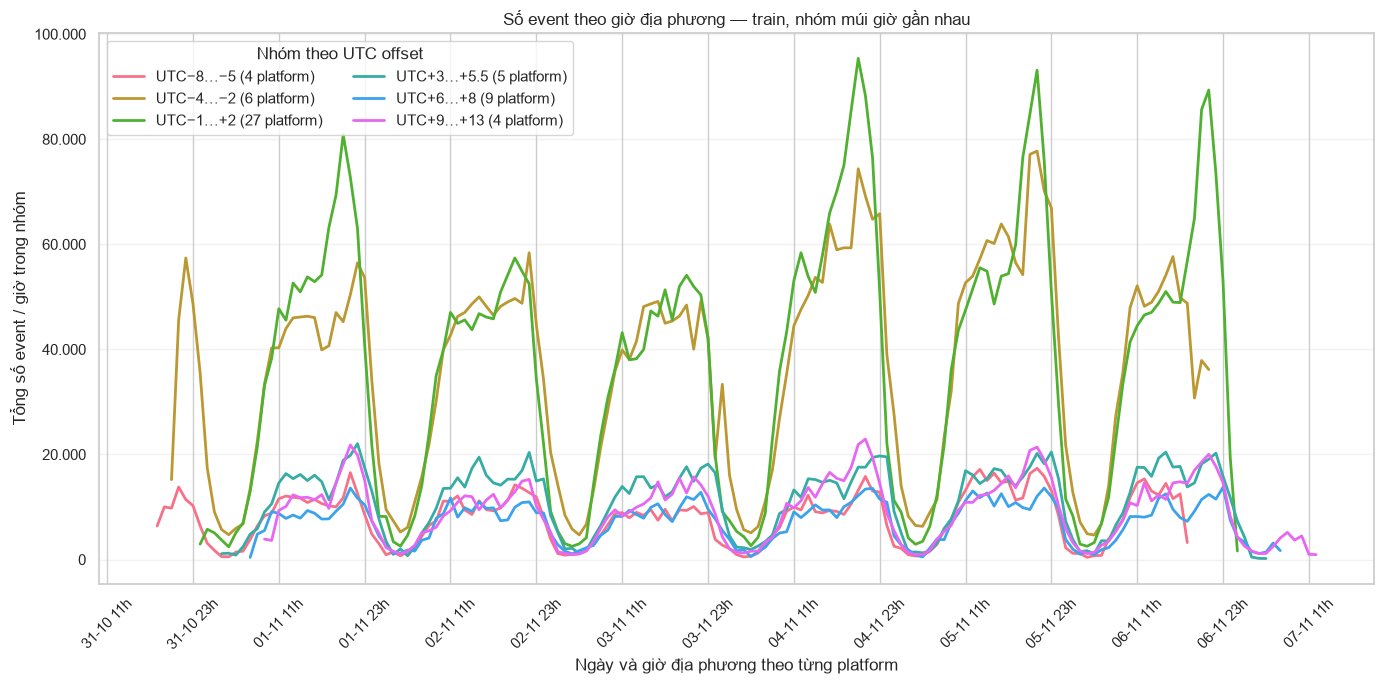

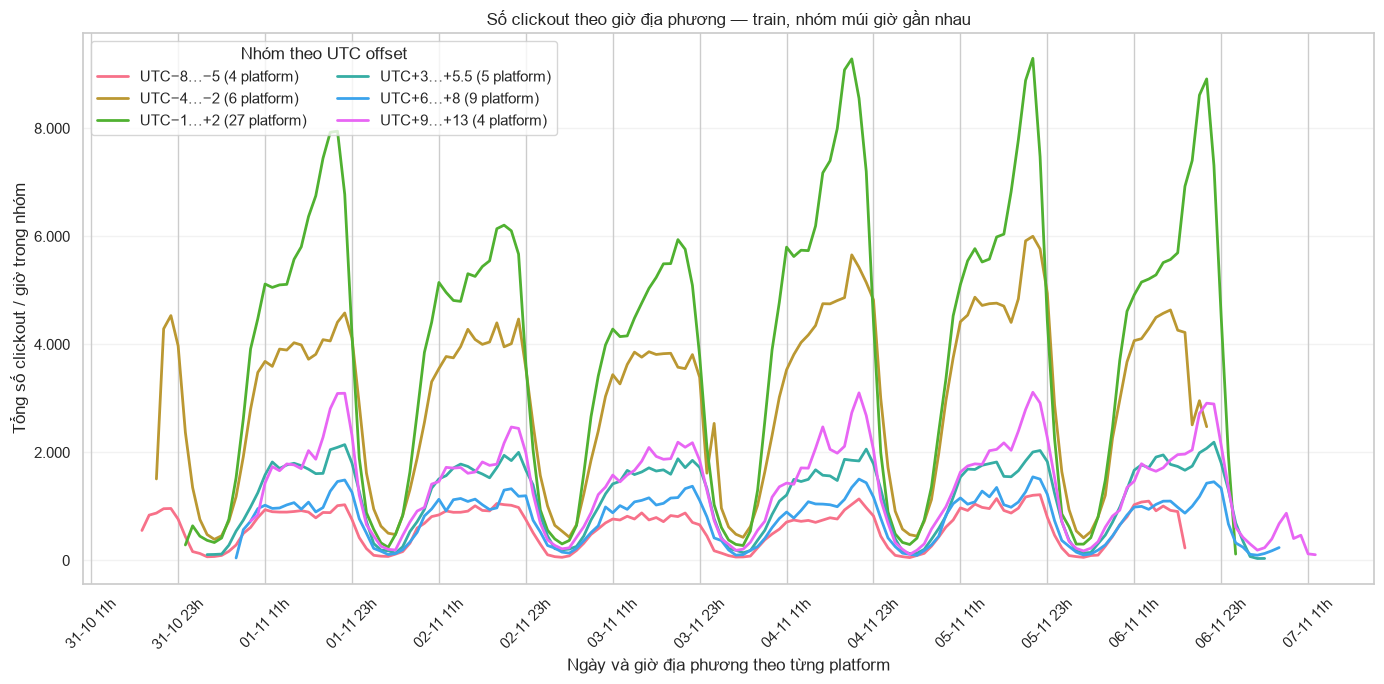

In [4]:
# Cell 3A: Số event và số click theo giờ địa phương, mọi khu vực (train)
# Phạm vi: toàn bộ platform trong train; một đường cho mỗi khu vực
# Output: hai biểu đồ riêng, event count và clickout count theo giờ địa phương
platform_timezone = {
    'AA': ('Thế giới Ả Rập', 'Asia/Riyadh'),
    'AE': ('Các Tiểu vương quốc Ả Rập Thống nhất', 'Asia/Dubai'),
    'AR': ('Argentina', 'America/Argentina/Buenos_Aires'),
    'AT': ('Áo', 'Europe/Vienna'),
    'AU': ('Úc', 'Australia/Sydney'),
    'BE': ('Bỉ', 'Europe/Brussels'),
    'BG': ('Bulgaria', 'Europe/Sofia'),
    'BR': ('Brazil', 'America/Sao_Paulo'),
    'CA': ('Canada', 'America/Toronto'),
    'CH': ('Thụy Sĩ', 'Europe/Zurich'),
    'CL': ('Chile', 'America/Santiago'),
    'CN': ('Trung Quốc', 'Asia/Shanghai'),
    'CO': ('Colombia', 'America/Bogota'),
    'CZ': ('Séc', 'Europe/Prague'),
    'DE': ('Đức', 'Europe/Berlin'),
    'DK': ('Đan Mạch', 'Europe/Copenhagen'),
    'EC': ('Ecuador', 'America/Guayaquil'),
    'ES': ('Tây Ban Nha', 'Europe/Madrid'),
    'FI': ('Phần Lan', 'Europe/Helsinki'),
    'FR': ('Pháp', 'Europe/Paris'),
    'GR': ('Hy Lạp', 'Europe/Athens'),
    'HK': ('Hồng Kông', 'Asia/Hong_Kong'),
    'HR': ('Croatia', 'Europe/Zagreb'),
    'HU': ('Hungary', 'Europe/Budapest'),
    'ID': ('Indonesia', 'Asia/Jakarta'),
    'IE': ('Ireland', 'Europe/Dublin'),
    'IL': ('Israel', 'Asia/Jerusalem'),
    'IN': ('Ấn Độ', 'Asia/Kolkata'),
    'IT': ('Ý', 'Europe/Rome'),
    'JP': ('Nhật Bản', 'Asia/Tokyo'),
    'KR': ('Hàn Quốc', 'Asia/Seoul'),
    'MX': ('Mexico', 'America/Mexico_City'),
    'MY': ('Malaysia', 'Asia/Kuala_Lumpur'),
    'NL': ('Hà Lan', 'Europe/Amsterdam'),
    'NO': ('Na Uy', 'Europe/Oslo'),
    'NZ': ('New Zealand', 'Pacific/Auckland'),
    'PE': ('Peru', 'America/Lima'),
    'PH': ('Philippines', 'Asia/Manila'),
    'PL': ('Ba Lan', 'Europe/Warsaw'),
    'PT': ('Bồ Đào Nha', 'Europe/Lisbon'),
    'RO': ('Romania', 'Europe/Bucharest'),
    'RS': ('Serbia', 'Europe/Belgrade'),
    'RU': ('Nga', 'Europe/Moscow'),
    'SE': ('Thụy Điển', 'Europe/Stockholm'),
    'SG': ('Singapore', 'Asia/Singapore'),
    'SI': ('Slovenia', 'Europe/Ljubljana'),
    'SK': ('Slovakia', 'Europe/Bratislava'),
    'TH': ('Thái Lan', 'Asia/Bangkok'),
    'TR': ('Thổ Nhĩ Kỳ', 'Europe/Istanbul'),
    'TW': ('Đài Loan', 'Asia/Taipei'),
    'UK': ('Vương quốc Anh', 'Europe/London'),
    'US': ('Hoa Kỳ', 'America/New_York'),
    'UY': ('Uruguay', 'America/Montevideo'),
    'VN': ('Việt Nam', 'Asia/Ho_Chi_Minh'),
    'ZA': ('Nam Phi', 'Africa/Johannesburg'),
}

# Chỉ các platform quan sát được trong train; ánh xạ phải bao phủ đủ mọi khu vực.
train_event_totals = Counter()
for (_, platform_code), count in platform_train_minute_event_counts.items():
    train_event_totals[platform_code] += count
observed_platforms = set(train_event_totals)
unknown_platforms = observed_platforms - set(platform_timezone)
if unknown_platforms:
    raise ValueError(f'Chưa có múi giờ đại diện cho platform: {sorted(unknown_platforms)}')
platforms = sorted(observed_platforms)

# Nhóm theo UTC offset tại một mốc cố định nằm trong thời gian quan sát train.
# Mốc cố định giữ nguyên thành viên nhóm dù một số nơi đổi DST trong tuần dữ liệu.
reference_time_utc = pd.Timestamp('2018-11-03 12:00:00', tz='UTC')
timezone_bands = [
    (-8, -5, 'UTC−8…−5'),
    (-4, -2, 'UTC−4…−2'),
    (-1, 2, 'UTC−1…+2'),
    (3, 5.5, 'UTC+3…+5.5'),
    (6, 8, 'UTC+6…+8'),
    (9, 13, 'UTC+9…+13'),
]
platform_group = {}
for code in platforms:
    timezone_name = platform_timezone[code][1]
    offset_hours = reference_time_utc.tz_convert(timezone_name).utcoffset().total_seconds() / 3600
    matching_bands = [
        label for lower, upper, label in timezone_bands
        if lower <= offset_hours <= upper
    ]
    if len(matching_bands) != 1:
        raise ValueError(f'UTC offset {offset_hours} của {code} chưa thuộc đúng một nhóm.')
    platform_group[code] = matching_bands[0]
group_labels = [
    label for _, _, label in timezone_bands
    if any(platform_group[code] == label for code in platforms)
]
group_sizes = Counter(platform_group.values())

# Quy đổi phút UTC theo múi giờ từng platform, gộp thành giờ địa phương,
# sau đó cộng các platform cùng nhóm tại cùng ngày-giờ địa phương.
def group_minute_counts_by_local_hour(minute_counter, platform_code, value_name):
    timezone_name = platform_timezone[platform_code][1]
    rows = [
        {'utc_minute': utc_minute, value_name: count}
        for (utc_minute, code), count in minute_counter.items()
        if code == platform_code
    ]
    if not rows:
        return pd.Series(dtype='int64', name=value_name)
    frame = pd.DataFrame(rows)
    frame['utc_minute'] = pd.to_datetime(frame['utc_minute'], utc=True)
    frame['local_hour'] = (
        frame['utc_minute'].dt.tz_convert(timezone_name).dt.floor(
            'h', ambiguous=False, nonexistent='shift_forward'
        ).dt.tz_localize(None)
    )
    return frame.groupby('local_hour')[value_name].sum().sort_index()


def sum_platforms_by_timezone_group(minute_counter, value_name):
    grouped = {label: pd.Series(dtype='int64', name=value_name) for label in group_labels}
    for code in platforms:
        local_hourly = group_minute_counts_by_local_hour(minute_counter, code, value_name)
        label = platform_group[code]
        grouped[label] = grouped[label].add(local_hourly, fill_value=0)
    return grouped


event_hourly_by_group = sum_platforms_by_timezone_group(
    platform_train_minute_event_counts, 'event_rows'
)
click_hourly_by_group = sum_platforms_by_timezone_group(
    platform_train_minute_click_counts, 'click_count'
)
group_colors = sns.color_palette('husl', n_colors=len(group_labels))


def plot_timezone_group_counts(series_by_group, title, ylabel):
    fig, ax = plt.subplots(figsize=(14, 7))
    for label, color in zip(group_labels, group_colors):
        series = series_by_group[label]
        ax.plot(
            series.index,
            series.values,
            color=color,
            linewidth=2,
            label=f'{label} ({group_sizes[label]} platform)',
        )
    ax.set_title(title)
    ax.set_xlabel('Ngày và giờ địa phương theo từng platform')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=12))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%m %Hh'))
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda value, _: f'{int(value):,}'.replace(',', '.'))
    )
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    ax.legend(title='Nhóm theo UTC offset', loc='best', ncol=2)
    plt.tight_layout()
    plt.show()


plot_timezone_group_counts(
    event_hourly_by_group,
    'Số event theo giờ địa phương — train, nhóm múi giờ gần nhau',
    'Tổng số event / giờ trong nhóm',
)
plot_timezone_group_counts(
    click_hourly_by_group,
    'Số clickout theo giờ địa phương — train, nhóm múi giờ gần nhau',
    'Tổng số clickout / giờ trong nhóm',
)


## 4. Schema/action_type

Bảng schema trước, sau đó action_type trong cùng cell.

,file,column,dtype,null_count,empty_count,missing_rate,unique_count,min,max,role,notes
0,train.csv,user_id,string (loaded),0,0,0.000000,730803,NaN,NaN,event identifier/context,full split DataFrame; rows preserved
1,train.csv,session_id,string (loaded),0,0,0.000000,910683,NaN,NaN,event identifier/context,full split DataFrame; rows preserved
2,train.csv,timestamp,string (loaded),0,0,0.000000,not_computed,1.541030e+09,1.541549e+09,event identifier/context,full split DataFrame; rows preserved
3,train.csv,step,string (loaded),0,0,0.000000,not_computed,NaN,NaN,event identifier/context,full split DataFrame; rows preserved
4,train.csv,action_type,string (loaded),0,0,0.000000,10,NaN,NaN,event context,full split DataFrame; rows preserved
5,train.csv,reference,string (loaded),0,0,0.000000,not_computed,NaN,NaN,action-dependent value; hotel ID only for qual...,full split DataFrame; rows preserved
6,train.csv,platform,string (loaded),0,0,0.000000,not_computed,NaN,NaN,event context,full split DataFrame; rows preserved
7,train.csv,city,string (loaded),0,0,0.000000,not_computed,NaN,NaN,event context,full split DataFrame; rows preserved
8,train.csv,device,string (loaded),0,0,0.000000,not_computed,NaN,NaN,event context,full split DataFrame; rows preserved
9,train.csv,current_filters,string (loaded),14779880,0,0.927627,not_computed,NaN,NaN,event context,full split DataFrame; rows preserved


,file,action_type,event_count,event_share
10,test.csv,interaction item image,2578455,0.681710
11,test.csv,clickout item,528779,0.139802
12,test.csv,filter selection,193499,0.051159
13,test.csv,change of sort order,117826,0.031152
14,test.csv,search for destination,115144,0.030443
15,test.csv,interaction item info,68101,0.018005
16,test.csv,interaction item rating,53704,0.014199
17,test.csv,search for item,43065,0.011386
18,test.csv,interaction item deals,42147,0.011143
19,test.csv,search for poi,41615,0.011002


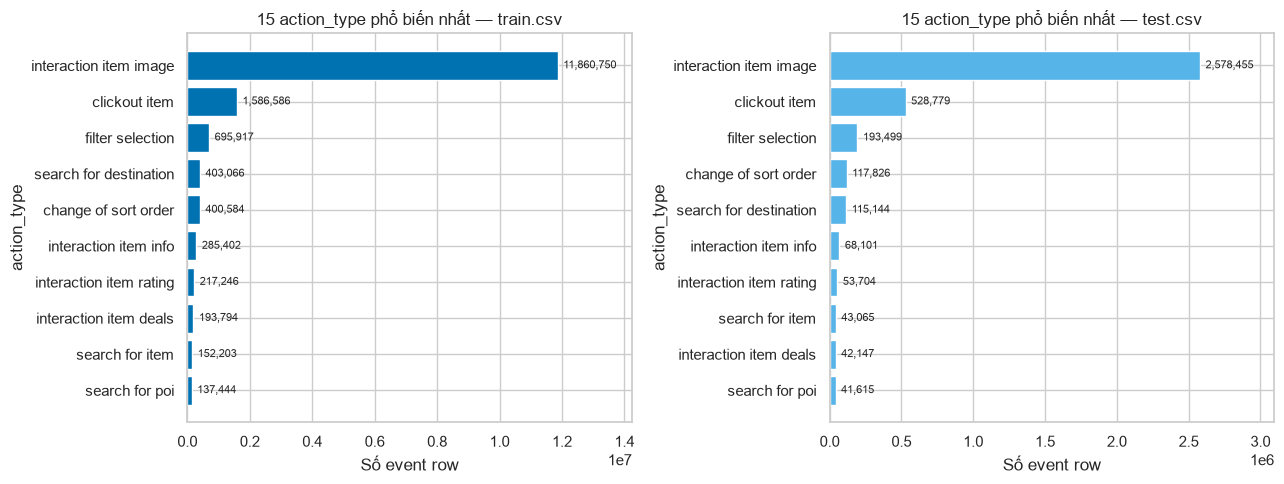

In [5]:
# Cell 4: Schema và action_type
# Input/phạm vi: train/test full-data
# Output: bảng schema, bảng action_type và biểu đồ phân bố hành động
schema_rows = []
for file_name, columns in [("train.csv", train_schema), ("test.csv", test_schema)]:
    observed_rows = row_counts[file_name]
    for column in columns:
        missing_count = null_counts[(file_name, column)]
        empty_count = empty_counts[(file_name, column)]
        unique_count = (
            len(unique_values[(file_name, column)])
            if column in {"user_id", "session_id", "action_type"}
            else "not_computed"
        )
        minimum = maximum = None
        if column == "timestamp" and file_name in timestamp_minmax:
            minimum, maximum = timestamp_minmax[file_name]

        role = "event context"
        if column in {"user_id", "session_id", "timestamp", "step"}:
            role = "event identifier/context"
        elif column == "reference":
            role = "action-dependent value; hotel ID only for qualifying item actions"
        elif column in {"impressions", "prices"}:
            role = "positional candidate list / aligned price list at clickout"

        schema_rows.append({
            "file": file_name,
            "column": column,
            "dtype": "string (loaded)",
            "null_count": missing_count,
            "empty_count": empty_count,
            "missing_rate": (
                (missing_count + empty_count) / observed_rows
                if observed_rows
                else np.nan
            ),
            "unique_count": unique_count,
            "min": minimum,
            "max": maximum,
            "role": role,
            "notes": "full split DataFrame; rows preserved",
        })

schema_table = pd.DataFrame(schema_rows)
display(schema_table)

action_summary = pd.DataFrame([
    {"file": file_name, "action_type": action, "event_count": count}
    for (file_name, action), count in action_counts.items()
]).sort_values(
    ["file", "event_count", "action_type"],
    ascending=[True, False, True],
)
action_summary["event_share"] = (
    action_summary["event_count"]
    / action_summary.groupby("file")["event_count"].transform("sum")
)
display(action_summary)

fig_action, axes_action = plt.subplots(1, 2, figsize=(13, 5))
for axis, file_name in zip(axes_action, ["train.csv", "test.csv"]):
    file_actions = action_summary[action_summary["file"].eq(file_name)].head(15)
    bars = axis.barh(
        file_actions["action_type"][::-1],
        file_actions["event_count"][::-1],
        color=SPLIT_COLORS[file_name.replace(".csv", "")],
    )
    axis.bar_label(
        bars,
        labels=[f"{int(value):,}" for value in file_actions["event_count"][::-1]],
        padding=4,
        fontsize=8,
    )
    axis.set_xlim(0, file_actions["event_count"].max() * 1.2)
    axis.set_title(f"15 action_type phổ biến nhất — {file_name}")
    axis.set_xlabel("Số event row")
    axis.set_ylabel("action_type")
fig_action.tight_layout()
plt.show()


**Nhận định schema.** Missingness dùng số event làm mẫu số; thiếu không tự động là lỗi.

**Nhận định action_type.** Phân bố hành động không đo chất lượng recommendation.

## 5. Độ dài session

Session length là số event; X là thứ hạng sau sắp xếp.

,file,sessions,events,min_events_per_session,max_events_per_session,mean_events_per_session,p50,p90,p99
0,train.csv,910683,15932992,1,3522,17.495651,4.0,41.0,212.0
1,test.csv,291381,3782335,1,2815,12.980719,3.0,31.0,152.0


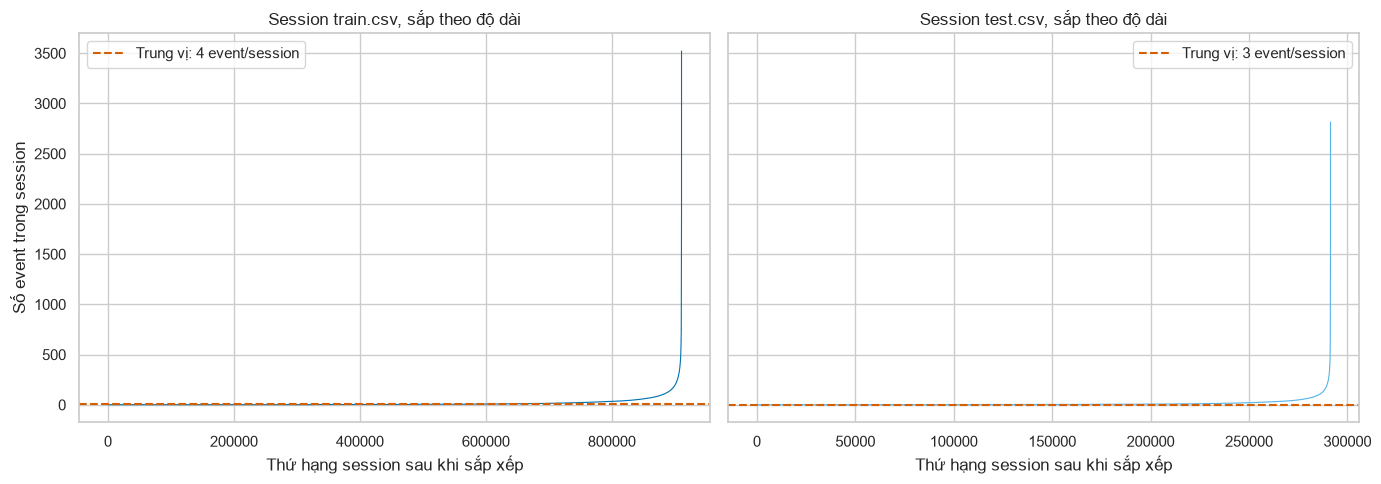

In [6]:
# Cell 5: Độ dài session
# Input/phạm vi: session theo khóa kép (user_id, session_id)
# Output: min/max, phân vị và đường phân bố đã sắp xếp
session_length_arrays = {}
session_length_rows = []

for file_name in ["train.csv", "test.csv"]:
    lengths = np.sort(np.asarray([
        event_count
        for (split_name, _session_key), event_count in session_events.items()
        if split_name == file_name
    ], dtype=np.int64))
    session_length_arrays[file_name] = lengths
    session_length_rows.append({
        "file": file_name,
        "sessions": len(lengths),
        "events": row_counts[file_name],
        "min_events_per_session": int(lengths.min()) if len(lengths) else np.nan,
        "max_events_per_session": int(lengths.max()) if len(lengths) else np.nan,
        "mean_events_per_session": lengths.mean() if len(lengths) else np.nan,
        "p50": np.quantile(lengths, 0.50) if len(lengths) else np.nan,
        "p90": np.quantile(lengths, 0.90) if len(lengths) else np.nan,
        "p99": np.quantile(lengths, 0.99) if len(lengths) else np.nan,
    })

session_length_summary = pd.DataFrame(session_length_rows)
display(session_length_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, file_name, color in zip(
    axes,
    ["train.csv", "test.csv"],
    [SPLIT_COLORS["train"], SPLIT_COLORS["test"]],
):
    lengths = session_length_arrays[file_name]
    if len(lengths):
        axis.plot(np.arange(1, len(lengths) + 1), lengths, color=color, linewidth=0.8)
        median_length = np.median(lengths)
        axis.axhline(
            median_length,
            color=COLORS["negative"],
            linestyle="--",
            label=f"Trung vị: {median_length:g} event/session",
        )
        axis.legend()
    axis.set(
        title=f"Session {file_name}, sắp theo độ dài",
        xlabel="Thứ hạng session sau khi sắp xếp",
        ylabel="Số event trong session",
    )
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


### Số phiên trên mỗi user và thống kê thời lượng phiên

Biểu đồ cho biết phân bố số session trên mỗi user, tách riêng train/test; nhóm các mức dài thành khoảng để dễ đọc. Bảng bên dưới tóm tắt thời lượng theo giờ: nhỏ nhất, P50, P90, P99 và lớn nhất cho mỗi file.

Độ dài tính theo khóa `(file, user_id, session_id)` hiện dùng trong notebook bằng `max(timestamp) - min(timestamp)`; đây là thời gian giữa event đầu và cuối, không phải thời gian user hoạt động liên tục. Session ID bị dùng lại trong cùng user có thể tạo khoảng kéo dài bất thường.


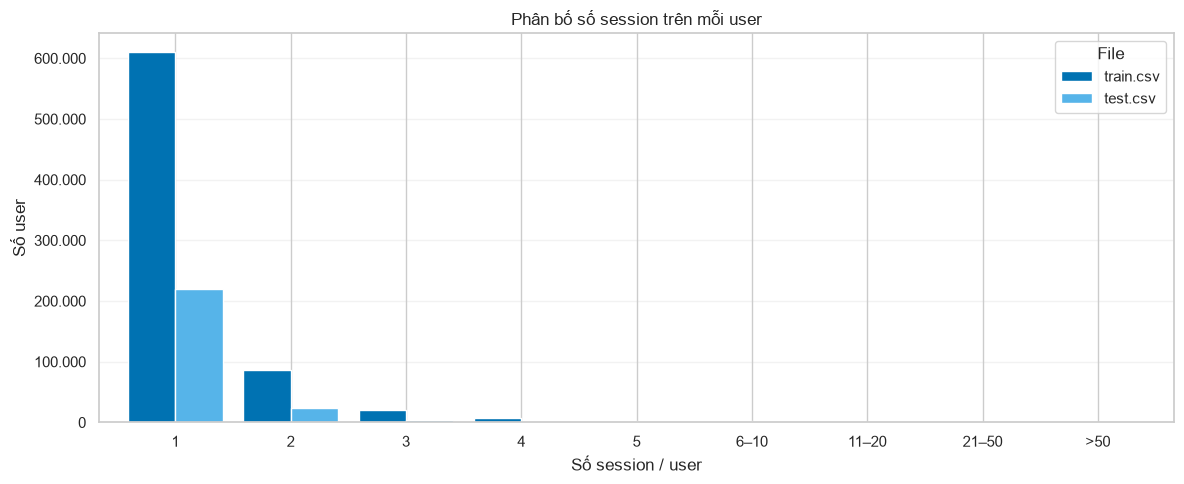

,file,min_time_hours,P50_hours,P90_hours,P99_hours,max_time_hours
0,train.csv,0.0,0.031,0.367,1.370,112.334
1,test.csv,0.0,0.024,0.300,1.232,25.398


In [7]:
# Cell 5A: Số session trên mỗi user và thời lượng phiên theo thời gian
# Input/phạm vi: session_events và session_time_bounds đã tích lũy ở Cell 3
# Output: biểu đồ phân bố session/user và bảng min/P50/P90/P99/max thời lượng
from collections import Counter

# Đếm session duy nhất cho từng user trong từng file theo khóa hiện dùng.
sessions_per_user_counter = Counter()
for file_name, session_key in session_events:
    user_id, session_id = session_key
    sessions_per_user_counter[(file_name, user_id)] += 1

# Gom phần đuôi dài để số user ở các mức session thấp vẫn dễ so sánh.
session_bin_labels = ['1', '2', '3', '4', '5', '6–10', '11–20', '21–50', '>50']
session_user_bin_counts = Counter()
for (file_name, user_id), count in sessions_per_user_counter.items():
    if count <= 5:
        group = str(count)
    elif count <= 10:
        group = '6–10'
    elif count <= 20:
        group = '11–20'
    elif count <= 50:
        group = '21–50'
    else:
        group = '>50'
    session_user_bin_counts[(file_name, group)] += 1
user_distribution = pd.DataFrame(
    {
        file_name: [session_user_bin_counts[(file_name, label)] for label in session_bin_labels]
        for file_name in ['train.csv', 'test.csv']
    },
    index=session_bin_labels,
)
fig, ax = plt.subplots(figsize=(12, 5))
user_distribution.plot(
    kind='bar',
    ax=ax,
    color=[SPLIT_COLORS['train'], SPLIT_COLORS['test']],
    width=0.82,
)
ax.set(
    title='Phân bố số session trên mỗi user',
    xlabel='Số session / user',
    ylabel='Số user',
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f'{int(value):,}'.replace(',', '.'))
)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
ax.legend(title='File')
plt.tight_layout()
plt.show()

# Chuẩn bị mảng gọn theo split; trục x là thứ tự session sau khi sắp theo lúc bắt đầu.
files = ['train.csv', 'test.csv']
duration_capacity = Counter(key[0] for key in session_time_bounds)
duration_arrays = {
    file_name: np.empty((duration_capacity[file_name], 2), dtype=np.float64)
    for file_name in files
}
duration_rows_written = Counter()
for (file_name, session_key), (start_timestamp, end_timestamp) in session_time_bounds.items():
    if file_name not in duration_arrays or pd.isna(start_timestamp) or pd.isna(end_timestamp):
        continue
    duration_hours = max(0.0, float(end_timestamp) - float(start_timestamp)) / 3600
    row_index = duration_rows_written[file_name]
    duration_arrays[file_name][row_index] = (float(start_timestamp), duration_hours)
    duration_rows_written[file_name] += 1

# Thống kê thời lượng theo từng split; các phân vị đo bằng giờ/session.
duration_summary_rows = []
for file_name in files:
    durations = duration_arrays[file_name][:duration_rows_written[file_name], 1]
    if len(durations):
        duration_summary_rows.append(
            {
                'file': file_name,
                'min_time_hours': float(np.min(durations)),
                'P50_hours': float(np.quantile(durations, 0.50)),
                'P90_hours': float(np.quantile(durations, 0.90)),
                'P99_hours': float(np.quantile(durations, 0.99)),
                'max_time_hours': float(np.max(durations)),
            }
        )
duration_summary = pd.DataFrame(duration_summary_rows)
display(duration_summary.round(3))


Đơn vị thời gian là giờ


## 6. Chất lượng dữ liệu

Duplicate được kiểm tra trên toàn bộ từng DataFrame train/test.
Số được báo là số dòng thuộc nhóm trùng, không phải số dòng dư sau khi giữ bản ghi đầu tiên.


,scope,observed_value,unit,status,denominator,evidence,notes
0,train.csv,15932992,event row,measured,15932992,len của split DataFrame đầy đủ,header không tính vào số dòng
1,train.csv,1586586,clickout query,measured,15932992,action_type == 'clickout item',query_id có thể tạo từ source_file và source_r...
2,train.csv,0,timestamp parse failure,measured,15932992,timestamp không chuyển được sang số,timestamp được giả định là Unix seconds UTC
3,train.csv,0,negative timestamp,measured,15932992,timestamp < 0,không xóa dòng
4,train.csv,0,missing/non-integer/step < 1,measured,15932992,numeric step validation,rows preserved
5,train.csv,0,rows in duplicate candidate-key groups,measured,15932992,"user_id, session_id, timestamp, step",checked across the complete split DataFrame
6,train.csv,0,rows in duplicate full-row groups,measured,15932992,full-row duplicate check,checked across the complete split DataFrame
7,test.csv,3782335,event row,measured,3782335,len của split DataFrame đầy đủ,header không tính vào số dòng
8,test.csv,528779,clickout query,measured,3782335,action_type == 'clickout item',query_id có thể tạo từ source_file và source_r...
9,test.csv,0,timestamp parse failure,measured,3782335,timestamp không chuyển được sang số,timestamp được giả định là Unix seconds UTC


,file,column,null_count,empty_count,missing_count,denominator,missing_rate
0,train.csv,user_id,0,0,0,15932992,0.000000
1,train.csv,session_id,0,0,0,15932992,0.000000
2,train.csv,timestamp,0,0,0,15932992,0.000000
3,train.csv,step,0,0,0,15932992,0.000000
4,train.csv,action_type,0,0,0,15932992,0.000000
5,train.csv,reference,0,0,0,15932992,0.000000
6,train.csv,platform,0,0,0,15932992,0.000000
7,train.csv,city,0,0,0,15932992,0.000000
8,train.csv,device,0,0,0,15932992,0.000000
9,train.csv,current_filters,14779880,0,14779880,15932992,0.927627


,file,reference_type,count
0,train.csv,numeric,1586586
1,train.csv,non_numeric,0
2,test.csv,numeric,275206
3,test.csv,non_numeric,0


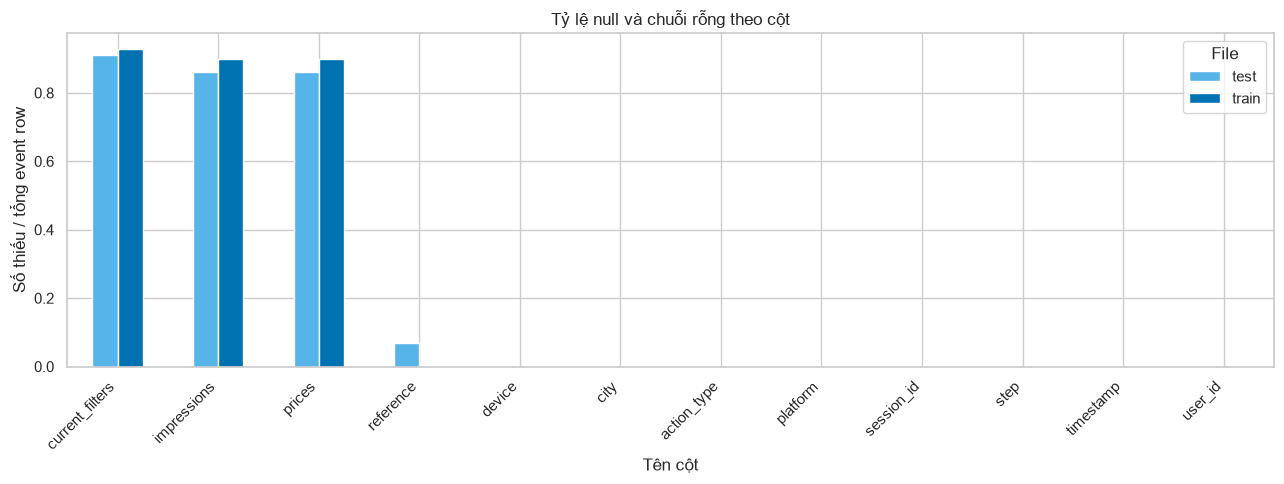

In [8]:
# Cell 6: Chất lượng dữ liệu và missingness
# Input/phạm vi: toàn bộ train/test; duplicate trên từng split DataFrame đầy đủ
# Output: bảng chất lượng, missingness, loại reference và biểu đồ
quality_rows = []
missingness_rows = []

for file_name in ["train.csv", "test.csv"]:
    total_rows = row_counts[file_name]
    quality_rows.extend([
        {
            "scope": file_name,
            "observed_value": total_rows,
            "unit": "event row",
            "status": "measured",
            "denominator": total_rows,
            "evidence": "len của split DataFrame đầy đủ",
            "notes": "header không tính vào số dòng",
        },
        {
            "scope": file_name,
            "observed_value": clickout_rows[file_name],
            "unit": "clickout query",
            "status": "measured",
            "denominator": total_rows,
            "evidence": "action_type == 'clickout item'",
            "notes": "query_id có thể tạo từ source_file và source_row_id",
        },
        {
            "scope": file_name,
            "observed_value": bad_timestamp[file_name],
            "unit": "timestamp parse failure",
            "status": "measured",
            "denominator": total_rows,
            "evidence": "timestamp không chuyển được sang số",
            "notes": "timestamp được giả định là Unix seconds UTC",
        },
        {
            "scope": file_name,
            "observed_value": negative_timestamp[file_name],
            "unit": "negative timestamp",
            "status": "measured",
            "denominator": total_rows,
            "evidence": "timestamp < 0",
            "notes": "không xóa dòng",
        },
        {
            "scope": file_name,
            "observed_value": bad_step[file_name],
            "unit": "missing/non-integer/step < 1",
            "status": "measured",
            "denominator": total_rows,
            "evidence": "numeric step validation",
            "notes": "rows preserved",
        },
        {
            "scope": file_name,
            "observed_value": duplicate_key_group_rows[file_name],
            "unit": "rows in duplicate candidate-key groups",
            "status": "measured",
            "denominator": total_rows,
            "evidence": "user_id, session_id, timestamp, step",
            "notes": "checked across the complete split DataFrame",
        },
        {
            "scope": file_name,
            "observed_value": duplicate_full_group_rows[file_name],
            "unit": "rows in duplicate full-row groups",
            "status": "measured",
            "denominator": total_rows,
            "evidence": "full-row duplicate check",
            "notes": "checked across the complete split DataFrame",
        },
    ])

    columns = train_schema if file_name == "train.csv" else test_schema
    for column in columns:
        null_count = null_counts[(file_name, column)]
        empty_count = empty_counts[(file_name, column)]
        missing_count = null_count + empty_count
        missingness_rows.append({
            "file": file_name,
            "column": column,
            "null_count": null_count,
            "empty_count": empty_count,
            "missing_count": missing_count,
            "denominator": total_rows,
            "missing_rate": missing_count / total_rows if total_rows else np.nan,
        })

multi_user_session_ids = {
    session_id: users
    for session_id, users in session_id_users.items()
    if len(users) > 1
}
quality_rows.append({
    "scope": "train + test",
    "observed_value": len(multi_user_session_ids),
    "unit": "session_id linked to multiple user_id values",
    "status": "measured",
    "denominator": len(session_id_users),
    "evidence": "distinct user_id set for each session_id",
    "notes": "session aggregation uses composite key (user_id, session_id)",
})

quality_table = pd.DataFrame(quality_rows)
missingness_table = pd.DataFrame(missingness_rows)
reference_type_table = pd.DataFrame([
    {
        "file": file_name,
        "reference_type": reference_type,
        "count": reference_type_counts[(file_name, reference_type)],
    }
    for file_name in ["train.csv", "test.csv"]
    for reference_type in ["numeric", "non_numeric"]
])
display(quality_table)
display(missingness_table)
display(reference_type_table)

missing_plot = missingness_table.copy()
missing_plot["file_label"] = missing_plot["file"].str.replace(".csv", "", regex=False)
missing_wide = missing_plot.pivot(
    index="column",
    columns="file_label",
    values="missing_rate",
).fillna(0)
missing_wide = missing_wide.loc[
    missing_wide.max(axis=1).sort_values(ascending=False).index
]
missing_wide.plot(
    kind="bar",
    figsize=(13, 5),
    color=[SPLIT_COLORS.get(name, COLORS["neutral"]) for name in missing_wide.columns],
)
plt.title("Tỷ lệ null và chuỗi rỗng theo cột")
plt.xlabel("Tên cột")
plt.ylabel("Số thiếu / tổng event row")
plt.xticks(rotation=45, ha="right")
plt.legend(title="File")
plt.tight_layout()
plt.show()


**Nhận định.** `reference` phụ thuộc `action_type`; chỉ sáu action item đã khai báo mới được
coi là nguồn hotel ID và hotel ID phải là chuỗi số. `reference` clickout test có thể bị ẩn.
Session dùng khóa kép `(user_id, session_id)`; duplicate được kiểm tra trên toàn split.


## 7. Clickout và candidate

Đánh giá nhãn chỉ trên train có candidate hợp lệ.

,file,condition,count,unit
0,train.csv,missing_or_empty_reference,0,clickout query
1,train.csv,missing_or_empty_impressions,0,clickout query
2,train.csv,empty_candidate_token,0,candidate token
3,train.csv,invalid_candidate_token,0,candidate token
4,train.csv,no_parseable_candidate_ids,0,clickout query
5,train.csv,parseable_nonempty_impressions,1586586,clickout query
6,train.csv,labeled_with_parseable_impressions,1586586,clickout query
7,train.csv,clicked_item_not_in_impressions,749,clickout query
8,train.csv,clicked_item_in_impressions,1585837,clickout query
9,train.csv,duplicate_candidate_entries,0,clickout query


,file,clickout_query_count,reference_observed_count,reference_missing_count,impressions_missing_or_empty_count,impressions_present_no_parseable_item_count,impressions_with_parseable_candidate_count,labeled_query_with_parseable_candidate_count,clicked_item_in_impressions_count,clicked_item_outside_impressions_count,parseable_impressions_rate_of_clickouts,in_list_rate_of_labeled_candidate_queries
0,train.csv,1586586,1586586,0,0,0,1586586,1586586,1585837,749,1.0,0.999528
1,test.csv,528779,275206,253573,0,0,528779,275206,275059,147,1.0,0.999466


,label_status,query_count,denominator_labeled_candidate_queries,query_share
0,reference trong impressions,1585837,1586586,0.999528
1,reference ngoài impressions,749,1586586,0.000472


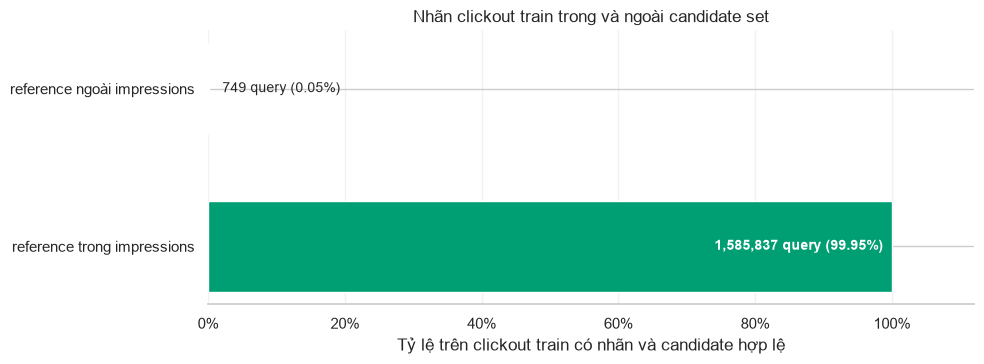

In [9]:
# Cell 7: Clickout, candidate và căn chỉnh prices
# Input/phạm vi: clickout train/test; nhãn đánh giá chỉ dùng train
# Output: bảng trạng thái, price QA và biểu đồ membership của nhãn train
reason_units = {
    "empty_candidate_token": "candidate token",
    "invalid_candidate_token": "candidate token",
    "duplicate_candidate_entry_count": "candidate token dư do trùng",
    "missing_aligned_price_pairs": "candidate-price pair",
    "extra_unaligned_price_entries": "price token dư",
}
reason_df = pd.DataFrame([
    {
        "file": file_name,
        "condition": condition,
        "count": clickout_reasons[(file_name, condition)],
        "unit": reason_units.get(condition, "clickout query"),
    }
    for file_name in ["train.csv", "test.csv"]
    for condition in CLICKOUT_REASON_NAMES
])
display(reason_df)

# Ba trạng thái impressions dưới đây loại trừ nhau và cộng lại thành tổng clickout query.
status_rows = []
for file_name in ["train.csv", "test.csv"]:
    total_clickouts = clickout_rows[file_name]
    missing_reference = clickout_reasons[(file_name, "missing_or_empty_reference")]
    missing_impressions = clickout_reasons[(file_name, "missing_or_empty_impressions")]
    parseable_impressions = clickout_reasons[(file_name, "parseable_nonempty_impressions")]
    present_without_parseable_item = (
        total_clickouts - missing_impressions - parseable_impressions
    )
    labeled_with_parseable = clickout_reasons[
        (file_name, "labeled_with_parseable_impressions")
    ]
    clicked_in = clickout_reasons[(file_name, "clicked_item_in_impressions")]
    clicked_out = clickout_reasons[(file_name, "clicked_item_not_in_impressions")]

    assert missing_impressions + present_without_parseable_item + parseable_impressions == total_clickouts
    assert clicked_in + clicked_out == labeled_with_parseable

    status_rows.append({
        "file": file_name,
        "clickout_query_count": total_clickouts,
        "reference_observed_count": total_clickouts - missing_reference,
        "reference_missing_count": missing_reference,
        "impressions_missing_or_empty_count": missing_impressions,
        "impressions_present_no_parseable_item_count": present_without_parseable_item,
        "impressions_with_parseable_candidate_count": parseable_impressions,
        "labeled_query_with_parseable_candidate_count": labeled_with_parseable,
        "clicked_item_in_impressions_count": clicked_in,
        "clicked_item_outside_impressions_count": clicked_out,
        "parseable_impressions_rate_of_clickouts": (
            parseable_impressions / total_clickouts if total_clickouts else np.nan
        ),
        "in_list_rate_of_labeled_candidate_queries": (
            clicked_in / labeled_with_parseable if labeled_with_parseable else np.nan
        ),
    })

clickout_candidate_summary = pd.DataFrame(status_rows)
display(clickout_candidate_summary)

# Chỉ train có nhãn đầy đủ để mô tả nhãn nằm trong candidate set.
labeled_candidate_queries = clickout_reasons[
    ("train.csv", "labeled_with_parseable_impressions")
]
clickout_membership = pd.DataFrame([
    {"label_status": "reference trong impressions", "query_count": clicked_in_list},
    {"label_status": "reference ngoài impressions", "query_count": clicked_out_of_list},
])
clickout_membership["denominator_labeled_candidate_queries"] = labeled_candidate_queries
clickout_membership["query_share"] = (
    clickout_membership["query_count"] / labeled_candidate_queries
    if labeled_candidate_queries
    else np.nan
)
display(clickout_membership)

fig, axis = plt.subplots(figsize=(10, 3.8))
labels = clickout_membership["label_status"].tolist()
shares = clickout_membership["query_share"].fillna(0).to_numpy()
counts = clickout_membership["query_count"].to_numpy()
bars = axis.barh(labels, shares, color=[COLORS["positive"], COLORS["negative"]], height=0.58)
for bar, count, share in zip(bars, counts, shares):
    label = f"{count:,} query ({share:.2%})"
    if share >= 0.15:
        axis.text(
            share - 0.012,
            bar.get_y() + bar.get_height() / 2,
            label,
            ha="right",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold",
        )
    else:
        axis.annotate(
            label,
            xy=(share, bar.get_y() + bar.get_height() / 2),
            xytext=(10, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
        )
axis.set_xlim(0, 1.12)
axis.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
axis.set(
    title="Nhãn clickout train trong và ngoài candidate set",
    xlabel="Tỷ lệ trên clickout train có nhãn và candidate hợp lệ",
)
axis.grid(axis="x", alpha=0.25)
axis.set_axisbelow(True)
axis.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()


**Nhận định.** Reference trong impressions đo độ bao phủ candidate set, không phải accuracy hay booking.

## 8. Độ thưa

S = 1 − |E|/(|L|×|R|); cặp vắng không đồng nghĩa dislike.

In [10]:
# Cell 8: Độ thưa S
# Input/phạm vi: quan hệ session-item, user-item train; query-item train+test
# Output: số nút, cạnh duy nhất, số cặp tối đa và S = 1 - |E|/(|L|*|R|)
def sparsity_row(name, left_count, item_count, edge_count):
    possible_pairs = left_count * item_count
    return {
        "Quan hệ": name,
        "Số nút trái": left_count,
        "Số khách sạn": item_count,
        "Số cặp duy nhất": edge_count,
        "Số cặp tối đa": possible_pairs,
        "Độ thưa S (%)": (
            1 - edge_count / possible_pairs if possible_pairs else np.nan
        ),
    }


session_edges = set(positive_session_item)
user_edges = set(positive_user_item)
valid_query_count = sum(
    clickout_reasons[(file_name, "parseable_nonempty_impressions")]
    for file_name in ["train.csv", "test.csv"]
)
query_candidate_edge_count = sum(candidate_count.values())

sparsity_table = pd.DataFrame([
    sparsity_row(
        "Session-khách sạn đã click (train)",
        len({session for session, _item in session_edges}),
        len({item for _session, item in session_edges}),
        len(session_edges),
    ),
    sparsity_row(
        "User-khách sạn đã click (train)",
        len({user for user, _item in user_edges}),
        len({item for _user, item in user_edges}),
        len(user_edges),
    ),
    sparsity_row(
        "Clickout query-khách sạn trong impressions (train + test)",
        valid_query_count,
        len(candidate_item_ids),
        query_candidate_edge_count,
    ),
])
sparsity_table["Độ thưa S (%)"] = sparsity_table["Độ thưa S (%)"].map(
    lambda value: f"{value:.2%}" if pd.notna(value) else "—"
)
display(sparsity_table)


,Quan hệ,Số nút trái,Số khách sạn,Số cặp duy nhất,Số cặp tối đa,Độ thưa S (%)
0,Session-khách sạn đã click (train),826842,289506,1354909,239375720052,100.00%
1,User-khách sạn đã click (train),717774,289506,1306901,207799879644,100.00%
2,Clickout query-khách sạn trong impressions (tr...,2115365,905289,48524284,1915016665485,100.00%


**Nhận định.** S cao phản ánh quan hệ thưa, không nói người dùng không thích cặp vắng.

## 9. Gini theo độ rộng tương tác của user

Với mỗi user train, đếm số hotel ID duy nhất trong sáu action trực tiếp đã khai báo.
User không có tương tác hotel hợp lệ vẫn được giữ với giá trị 0 trong mẫu số Gini.


In [11]:
# Cell 9: Gini theo số khách sạn tương tác trên mỗi user
# Input/phạm vi: train; sáu action hotel trực tiếp; hotel ID dạng số
# Output: số hotel duy nhất/user (kể cả 0) và hệ số Gini chuẩn
train_users = sorted({
    user_id
    for raw_user_id in unique_values[("train.csv", "user_id")]
    if (user_id := clean_id(raw_user_id)) is not None
})
interacted_hotel_count_by_user = Counter(
    user_id for user_id, _hotel_id in user_hotel_interactions
)
user_hotel_counts = np.sort(np.asarray([
    interacted_hotel_count_by_user.get(user_id, 0)
    for user_id in train_users
], dtype=float))

if len(user_hotel_counts) and user_hotel_counts.sum() > 0:
    user_count = len(user_hotel_counts)
    ranks = np.arange(1, user_count + 1, dtype=float)
    gini_value = (
        2 * np.sum(ranks * user_hotel_counts)
        / (user_count * user_hotel_counts.sum())
        - (user_count + 1) / user_count
    )
    gini_status = "measured"
else:
    gini_value = np.nan
    gini_status = "not_applicable"

gini_table = pd.DataFrame([{
    "Số user train": len(train_users),
    "User có hotel interaction": int((user_hotel_counts > 0).sum()),
    "User có 0 hotel interaction": int((user_hotel_counts == 0).sum()),
    "Cặp (user_id, hotel_id) duy nhất": len(user_hotel_interactions),
    "Hệ số Gini (0-1)": gini_value,
    "Đơn vị": "số hotel ID duy nhất / user",
    "Trạng thái": gini_status,
}])
display(gini_table)


,Số user train,User có hotel interaction,User có 0 hotel interaction,"Cặp (user_id, hotel_id) duy nhất",Hệ số Gini (0-1),Đơn vị,Trạng thái
0,730803,725968,4835,1982871,0.467517,số hotel ID duy nhất / user,measured


**Nhận định.** Gini đo bất bình đẳng về số khách sạn được mỗi user tương tác trong train.
Chỉ số giữ cả user có 0 hotel interaction; nó không đo accuracy và không giải thích nguyên nhân hành vi.


## 10. Candidate/query

Candidate/query là số khách sạn duy nhất trong impressions.

,Số clickout query,Trung vị,P90,P95,P99,Lớn nhất,Đúng 25 candidate (%),Ít hơn 25 candidate (%),Số query vượt 25
0,2115365,25.0,25.0,25.0,25.0,25,77.69%,22.31%,0


,Số candidate,Số clickout query,Tỷ lệ (%)
0,1,5715,0.27%
1,2,6895,0.33%
2,3,7581,0.36%
3,4,8226,0.39%
4,5,8854,0.42%
5,6,9516,0.45%
6,7,9970,0.47%
7,8,10486,0.50%
8,9,11471,0.54%
9,10,12940,0.61%


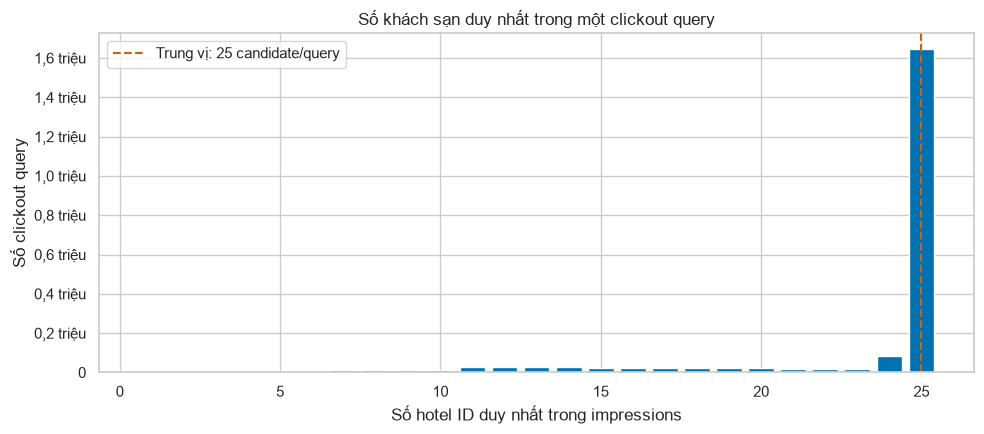

In [12]:
# Cell 10: Số candidate/query
# Input/phạm vi: clickout train+test có ít nhất một hotel ID hợp lệ trong impressions
# Output: phân vị, phân bố và biểu đồ candidate duy nhất/query
candidate_size_series = pd.Series(all_candidate_sizes, dtype="int64")

if candidate_size_series.empty:
    candidate_size_counts = pd.Series(dtype="int64")
    candidate_size_summary = pd.DataFrame([{
        "Số clickout query": 0,
        "Trạng thái": "not_applicable",
    }])
    candidate_size_distribution = pd.DataFrame()
else:
    candidate_size_counts = (
        candidate_size_series.value_counts()
        .sort_index()
        .reindex(range(1, int(candidate_size_series.max()) + 1), fill_value=0)
    )
    candidate_size_summary = pd.DataFrame([{
        "Số clickout query": len(candidate_size_series),
        "Trung vị": candidate_size_series.median(),
        "P90": candidate_size_series.quantile(0.90),
        "P95": candidate_size_series.quantile(0.95),
        "P99": candidate_size_series.quantile(0.99),
        "Lớn nhất": candidate_size_series.max(),
        "Đúng 25 candidate (%)": f"{candidate_size_series.eq(25).mean():.2%}",
        "Ít hơn 25 candidate (%)": f"{candidate_size_series.lt(25).mean():.2%}",
        "Số query vượt 25": int(candidate_size_series.gt(25).sum()),
    }])
    candidate_size_distribution = pd.DataFrame({
        "Số candidate": candidate_size_counts.index,
        "Số clickout query": candidate_size_counts.values,
        "Tỷ lệ (%)": candidate_size_counts.values / len(candidate_size_series),
    })

display(candidate_size_summary)
if not candidate_size_distribution.empty:
    display(candidate_size_distribution.assign(**{
        "Tỷ lệ (%)": candidate_size_distribution["Tỷ lệ (%)"].map(
            lambda value: f"{value:.2%}"
        )
    }))

if not candidate_size_series.empty:
    fig, axis = plt.subplots(figsize=(10, 4.5))
    axis.bar(candidate_size_counts.index, candidate_size_counts.values, color=COLORS["primary"])
    median_size = candidate_size_series.median()
    axis.axvline(
        median_size,
        color=COLORS["negative"],
        linestyle="--",
        label=f"Trung vị: {median_size:g} candidate/query",
    )
    axis.set(
        title="Số khách sạn duy nhất trong một clickout query",
        xlabel="Số hotel ID duy nhất trong impressions",
        ylabel="Số clickout query",
    )
    axis.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, _: "0" if value == 0 else f"{value / 1_000_000:.1f}".replace(".", ",") + " triệu"
        )
    )
    axis.legend()
    plt.tight_layout()
    plt.show()


**Nhận định.** Tỷ lệ đúng 25, dưới 25 và query vượt 25 dùng mẫu số query hợp lệ train/test.

## 11. Tỷ lệ được chọn

Tử số là candidate chọn; mẫu số là candidate hiển thị.

In [13]:
# Cell 11: Tỷ lệ candidate được chọn
# Input/phạm vi: train clickout có reference nằm trong impressions
# Output: selected candidate / candidate exposure, sau khi khử trùng ID trong từng query
eligible_queries = clicked_in_list
shown_candidates = sum(train_candidate_exposure.values())
selected_candidates = sum(train_clicked_candidate_by_item.values())
selected_rate = (
    selected_candidates / shown_candidates if shown_candidates else np.nan
)

display(pd.DataFrame([{
    "Clickout query đủ điều kiện": eligible_queries,
    "Candidate đã hiển thị": shown_candidates,
    "Candidate được chọn": selected_candidates,
    "Tỷ lệ được chọn (%)": (
        f"{selected_rate:.2%}" if pd.notna(selected_rate) else "—"
    ),
}]))


,Clickout query đủ điều kiện,Candidate đã hiển thị,Candidate được chọn,Tỷ lệ được chọn (%)
0,1585837,36361011,1585837,4.36%


**Nhận định.** Tỷ lệ được chọn không phải accuracy hay booking và phụ thuộc số candidate mỗi query.

## 12. Tỷ lệ session có clickout theo thiết bị

Mỗi session được gán theo thiết bị không thiếu xuất hiện đầu tiên. Tỷ lệ là số session có ít nhất một `clickout item` với `reference` chia tổng session trong nhóm thiết bị.


Session có thiết bị thiếu/ngoài ba nhóm: 0
Session ghi nhận nhiều hơn một loại thiết bị: 0


,Thiết bị của session,Số session,Số session có clickout,Tỷ lệ session có clickout (%)
0,mobile,534555,487707,91.24%
1,desktop,303713,272549,89.74%
2,tablet,72415,66586,91.95%


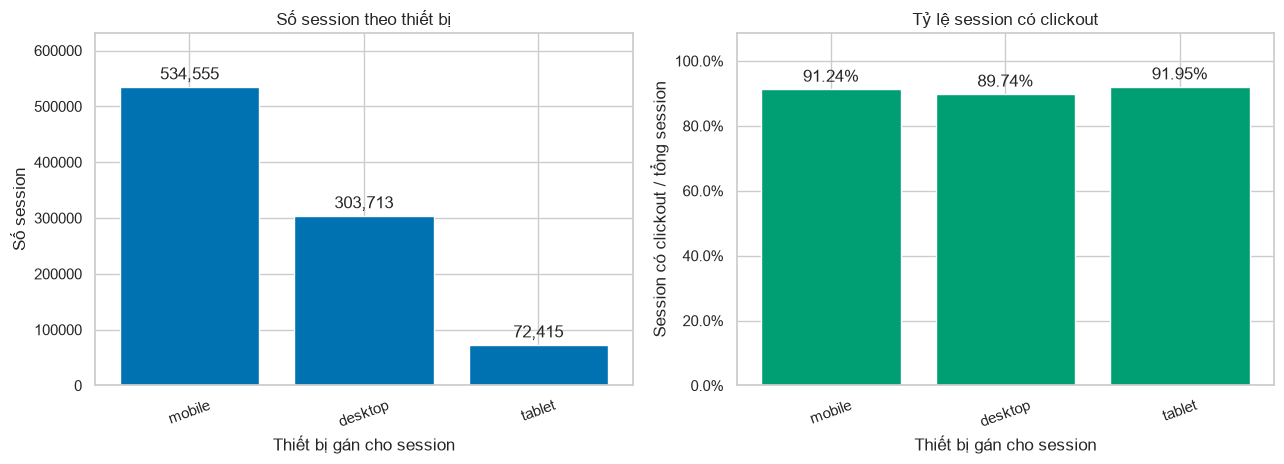

In [14]:
# Cell 12: Tỷ lệ session có clickout theo thiết bị
# Input/phạm vi: session train, khóa kép (user_id, session_id)
# Output: hai biểu đồ: số session và tỷ lệ session có clickout

device_order = ['mobile', 'desktop', 'tablet']
session_counts_by_device = Counter(train_session_device.values())
clickout_session_counts_by_device = Counter(
    train_session_device.get(session_key, '<missing>')
    for session_key in train_session_clickout_keys
)
unclassified_session_count = sum(
    count for device, count in session_counts_by_device.items()
    if device not in device_order
)
device_relation = pd.DataFrame([
    {
        'device': device,
        'session_count': session_counts_by_device.get(device, 0),
        'clickout_session_count': clickout_session_counts_by_device.get(device, 0),
    }
    for device in device_order
])
device_relation['session_clickout_rate'] = (
    device_relation['clickout_session_count']
    / device_relation['session_count'].replace(0, np.nan)
)
device_relation = device_relation.sort_values('session_count', ascending=False).reset_index(drop=True)

device_display = device_relation.rename(columns={
    'device': 'Thiết bị của session',
    'session_count': 'Số session',
    'clickout_session_count': 'Số session có clickout',
    'session_clickout_rate': 'Tỷ lệ session có clickout',
})
print(f"Session có thiết bị thiếu/ngoài ba nhóm: {unclassified_session_count:,}")
print(f"Session ghi nhận nhiều hơn một loại thiết bị: {len(train_session_device_conflicts):,}")

display(device_display.assign(**{
    'Tỷ lệ session có clickout (%)': device_display['Tỷ lệ session có clickout'].map(
        lambda value: f'{value:.2%}' if pd.notna(value) else '—'
    )
}).drop(columns='Tỷ lệ session có clickout'))

# Arial co san tren Windows va ho tro cac dau tieng Viet trong bieu do.
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(device_relation))

bars_sessions = axes[0].bar(
    x, device_relation['session_count'],
    color=COLORS['primary'],
)
axes[0].bar_label(bars_sessions, labels=[f'{v:,.0f}' for v in device_relation['session_count']], padding=3)
axes[0].set_xticks(x, device_relation['device'])
axes[0].set(title='Số session theo thiết bị', xlabel='Thiết bị gán cho session', ylabel='Số session')

bars_rate = axes[1].bar(
    x, device_relation['session_clickout_rate'],
    color=COLORS['positive'],
)
axes[1].bar_label(bars_rate, labels=[f'{value:.2%}' for value in device_relation['session_clickout_rate']], padding=3)
axes[1].set_xticks(x, device_relation['device'])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1%}'))
axes[1].set(title='Tỷ lệ session có clickout', xlabel='Thiết bị gán cho session', ylabel='Session có clickout / tổng session')
for axis in axes:
    axis.tick_params(axis='x', rotation=20)
    axis.margins(y=0.18)
fig.tight_layout()
plt.show()


**Nhận định.** Tỷ lệ trong biểu đồ là tỷ lệ session có clickout, không phải tỷ lệ đặt phòng. Nếu một session có nhiều thiết bị, session được xếp theo thiết bị không thiếu xuất hiện đầu tiên; số session có nhiều loại thiết bị được báo riêng.


## 13. Step đầu tiên

Session không click được báo riêng, không gán step 0.

,Trạng thái session,Số session,Tỷ lệ session (%)
0,Có clickout và step hợp lệ,826842,90.79%
1,Có clickout nhưng step không hợp lệ,0,0.00%
2,Không có clickout,83841,9.21%


,Số session có first_click_step hợp lệ,P50 step,P90 step,P99 step
0,826842,2.0,19.0,102.0


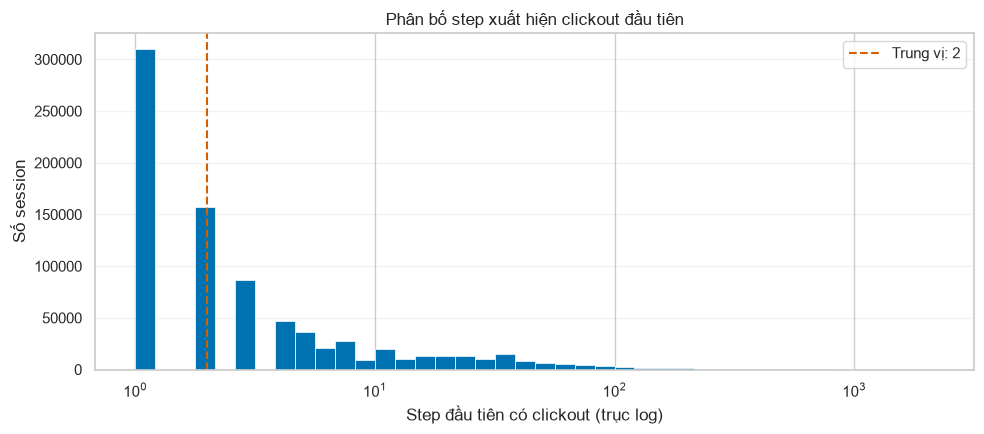

In [15]:
# Cell 13: Step clickout đầu tiên
# Input/phạm vi: toàn bộ session train
# Output: session có clickout/không clickout và phân vị first_click_step
session_rows = []
for (file_name, session_key), _event_count in session_events.items():
    if file_name != "train.csv":
        continue
    detail = train_session_details.get(session_key, {
        "max_step": np.nan,
        "clickout_count": 0,
        "first_click_step": np.nan,
    })
    bounds = session_time_bounds.get(("train.csv", session_key), (np.nan, np.nan))
    session_rows.append({
        "user_id": session_key[0],
        "session_id": session_key[1],
        "clickout_count": detail["clickout_count"],
        "first_click_step": detail["first_click_step"],
        "session_start_timestamp": bounds[0],
    })

session_click_summary = pd.DataFrame(session_rows)
session_click_summary["has_clickout"] = session_click_summary["clickout_count"].gt(0)
raw_steps = pd.to_numeric(session_click_summary["first_click_step"], errors="coerce")
valid_step_mask = raw_steps.notna() & raw_steps.ge(1) & raw_steps.mod(1).eq(0)
valid_first_click_steps = raw_steps.loc[valid_step_mask].astype("int64")

session_status = pd.DataFrame([
    {
        "Trạng thái session": "Có clickout và step hợp lệ",
        "Số session": int(valid_step_mask.sum()),
    },
    {
        "Trạng thái session": "Có clickout nhưng step không hợp lệ",
        "Số session": int((session_click_summary["has_clickout"] & ~valid_step_mask).sum()),
    },
    {
        "Trạng thái session": "Không có clickout",
        "Số session": int((~session_click_summary["has_clickout"]).sum()),
    },
])
session_status["Tỷ lệ session (%)"] = (
    session_status["Số session"] / len(session_click_summary)
)
display(session_status.assign(**{
    "Tỷ lệ session (%)": session_status["Tỷ lệ session (%)"].map(
        lambda value: f"{value:.2%}"
    )
}))
display(pd.DataFrame([{
    "Số session có first_click_step hợp lệ": len(valid_first_click_steps),
    "P50 step": valid_first_click_steps.quantile(0.50) if len(valid_first_click_steps) else np.nan,
    "P90 step": valid_first_click_steps.quantile(0.90) if len(valid_first_click_steps) else np.nan,
    "P99 step": valid_first_click_steps.quantile(0.99) if len(valid_first_click_steps) else np.nan,
}]))

if not valid_first_click_steps.empty:
    max_step = int(valid_first_click_steps.max())
    bin_count = min(40, max(2, max_step))
    bins = np.geomspace(1, max_step + 1, num=bin_count + 1)
    fig, axis = plt.subplots(figsize=(10, 4.5))
    axis.hist(
        valid_first_click_steps,
        bins=bins,
        color=COLORS["primary"],
        edgecolor="white",
        linewidth=0.5,
    )
    axis.set_xscale("log")
    median_step = float(valid_first_click_steps.median())
    axis.axvline(
        median_step,
        color=COLORS["negative"],
        linestyle="--",
        label=f"Trung vị: {median_step:g}",
    )
    axis.set(
        title="Phân bố step xuất hiện clickout đầu tiên",
        xlabel="Step đầu tiên có clickout (trục log)",
        ylabel="Số session",
    )
    axis.grid(axis="y", alpha=0.25)
    axis.legend()
    plt.tight_layout()
    plt.show()


**Nhận định.** first_click_step khác tổng độ dài session; event có thể tiếp tục sau clickout.

## 14. Theo user

User chưa click là chưa quan sát trong cửa sổ train.

,Trạng thái,Số user,Tỷ lệ user (%)
0,Chưa có clickout trong cửa sổ,13029,1.78%
1,Có clickout xếp theo thời gian,717774,98.22%


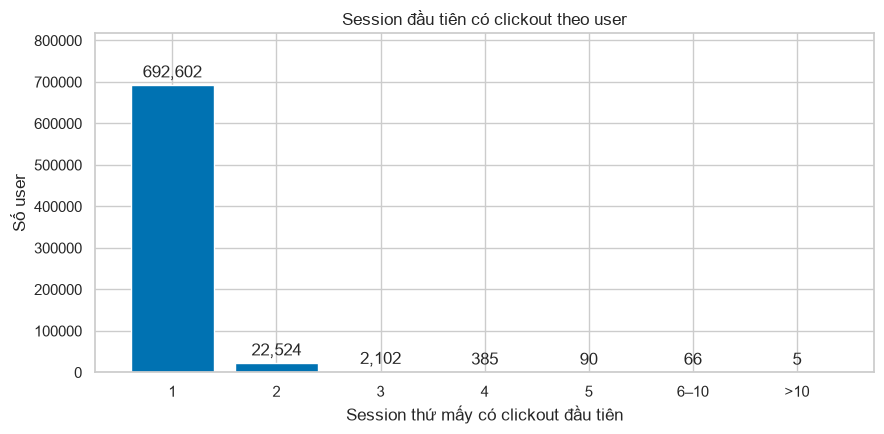

In [16]:
# Cell 14: Session clickout đầu tiên theo user
# Input/phạm vi: user train; session được xếp theo timestamp bắt đầu
# Output: trạng thái user và phân bố chỉ số session clickout đầu tiên
ordered_sessions = (
    session_click_summary
    .loc[session_click_summary["session_start_timestamp"].notna()]
    .sort_values(["user_id", "session_start_timestamp", "session_id"], kind="stable")
    .copy()
)
ordered_sessions["session_index"] = (
    ordered_sessions.groupby("user_id").cumcount() + 1
)
first_click_session = (
    ordered_sessions.loc[ordered_sessions["has_clickout"]]
    .groupby("user_id", as_index=False)["session_index"]
    .min()
    .rename(columns={"session_index": "first_click_session_index"})
)

all_train_users = pd.Index(
    session_click_summary["user_id"].dropna().unique(),
    name="user_id",
)
users_with_unordered_clickout = set(
    session_click_summary.loc[
        session_click_summary["has_clickout"]
        & session_click_summary["session_start_timestamp"].isna(),
        "user_id",
    ]
)
user_first_click_session = (
    pd.DataFrame({"user_id": all_train_users})
    .merge(first_click_session, on="user_id", how="left")
)
# Thiếu timestamp được ưu tiên báo là không xác định, kể cả user có session khác hợp lệ.
user_first_click_session["status"] = np.select(
    [
        user_first_click_session["user_id"].isin(users_with_unordered_clickout),
        user_first_click_session["first_click_session_index"].notna(),
    ],
    [
        "Có clickout nhưng thiếu timestamp",
        "Có clickout xếp theo thời gian",
    ],
    default="Chưa có clickout trong cửa sổ",
)

user_status_summary = (
    user_first_click_session.groupby("status", as_index=False)
    .size()
    .rename(columns={"status": "Trạng thái", "size": "Số user"})
)
user_status_summary["Tỷ lệ user (%)"] = (
    user_status_summary["Số user"] / len(user_first_click_session)
)
display(user_status_summary.assign(**{
    "Tỷ lệ user (%)": user_status_summary["Tỷ lệ user (%)"].map(
        lambda value: f"{value:.2%}"
    )
}))

observed_session_indices = user_first_click_session[
    "first_click_session_index"
].dropna()
if len(observed_session_indices):
    session_index_groups = pd.cut(
        observed_session_indices,
        [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 10.5, np.inf],
        labels=["1", "2", "3", "4", "5", "6–10", ">10"],
    )
    group_counts = session_index_groups.value_counts(sort=False)
    fig, axis = plt.subplots(figsize=(9, 4.5))
    bars = axis.bar(group_counts.index.astype(str), group_counts.values, color=COLORS["primary"])
    axis.bar_label(bars, labels=[f"{value:,}" for value in group_counts.values], padding=3)
    axis.set(
        title="Session đầu tiên có clickout theo user",
        xlabel="Session thứ mấy có clickout đầu tiên",
        ylabel="Số user",
    )
    axis.margins(y=0.18)
    plt.tight_layout()
    plt.show()


**Nhận định.** User chưa click không phải phản hồi tiêu cực.

## 15. Metadata/provenance

Kiểm tra số dòng, ID trùng, missing properties, hash.

In [17]:
# Cell 15: Metadata và provenance
# Input/phạm vi: metadata_df đầy đủ đã nạp ở Cell 2
# Output: tập hotel metadata, số property duy nhất/item và inventory
#
# Mọi trạng thái metadata được khởi tạo lại trong cell để chạy lại không cộng dồn.
metadata_null_counts = Counter()
metadata_seen_counts = Counter()
metadata_items = set()
metadata_item_properties = defaultdict(set)
metadata_rows = len(metadata_df)

for column in metadata_df.columns:
    metadata_null_counts[column] = int(metadata_df[column].isna().sum())

normalized_item_ids = metadata_df["item_id"].map(clean_hotel_id)
for item_id, raw_properties in zip(
    normalized_item_ids.array,
    metadata_df["properties"].array,
):
    if item_id is None:
        continue
    metadata_seen_counts[item_id] += 1
    metadata_items.add(item_id)
    property_tokens = split_pipe(raw_properties) or []
    metadata_item_properties[item_id].update(
        token.strip() for token in property_tokens if token.strip()
    )

metadata_item_property_counts = Counter({
    item_id: len(properties)
    for item_id, properties in metadata_item_properties.items()
})
metadata_property_counts = Counter(
    property_name
    for properties in metadata_item_properties.values()
    for property_name in properties
)

inventory_table = pd.DataFrame(inventory_records)
display(inventory_table)
print(
    "Số dòng metadata:", f"{metadata_rows:,}",
    "| số hotel ID duy nhất:", f"{len(metadata_items):,}",
    "| số dòng item_id trùng:",
    f"{sum(count - 1 for count in metadata_seen_counts.values()):,}",
)


,file,exists,bytes,modified_utc,header,sha256_before_scan,row_count,scope
0,D:\VSF\NBP_RecommendationSystem\sample_data\Tr...,True,2100807496,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,action_type,...",285f07abbc87ea22e608ce194ece7bcc1047926339e269...,15932992,DataFrame đầy đủ; header không tính vào row_count
1,D:\VSF\NBP_RecommendationSystem\sample_data\Tr...,True,534912813,2019-10-25T15:43:02+00:00,"user_id,session_id,timestamp,step,action_type,...",f5917f91b3e83910f076e94804b86acf5ef56b2af482db...,3782335,DataFrame đầy đủ; header không tính vào row_count
2,D:\VSF\NBP_RecommendationSystem\sample_data\Tr...,True,257901183,2019-10-25T15:43:02+00:00,"item_id,properties",b1757ea4eded7475c84763391ef8cff00ba707590886b6...,927142,DataFrame đầy đủ; header không tính vào row_count


Số dòng metadata: 927,142 | số hotel ID duy nhất: 927,142 | số dòng item_id trùng: 0


## 16. Coverage/property

“Hotel ID quan sát được” là hợp của hotel ID dạng số trong `impressions` và `reference`
thuộc sáu action đã khai báo, gộp train+test rồi khử trùng. Coverage dùng tập này làm mẫu số;
số property chỉ xét item có dòng metadata.


,Phạm vi,Hotel ID quan sát được,Có metadata,Không có metadata,Độ phủ metadata (%)
0,train.csv,872174,871301,873,99.90%
1,test.csv,628837,628262,575,99.91%
2,train + test (union),926457,925519,938,99.90%


,Số item metadata,Item có property,Trung vị property/item,P90,P95,P99,Lớn nhất
0,927142,927142,15.0,46.0,55.0,71.0,112


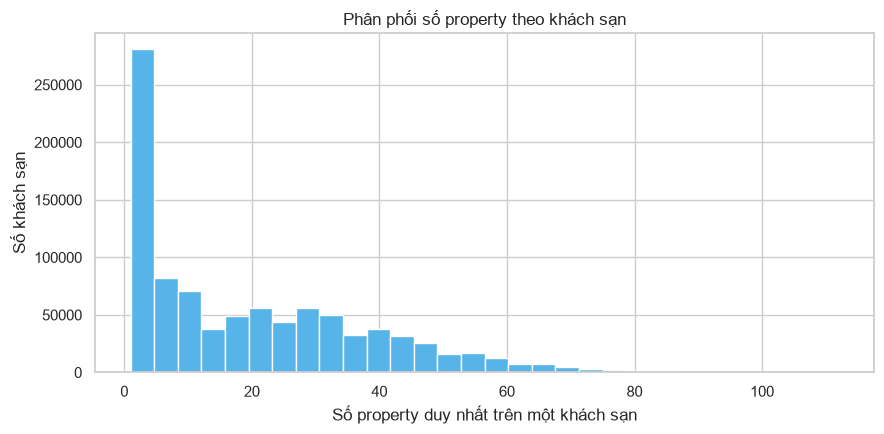

In [18]:
# Cell 16: Coverage metadata
# Input/phạm vi: hotel ID dạng số trong impressions hoặc sáu action reference, train+test
# Output: coverage metadata và phân bố số property/item
item_universe = set(observed_hotel_ids)
matched_items = item_universe & metadata_items
missing_metadata_items = item_universe - metadata_items

coverage_by_split = []
for file_name in ["train.csv", "test.csv"]:
    split_items = observed_hotel_ids_by_file[file_name]
    coverage_by_split.append({
        "Phạm vi": file_name,
        "Hotel ID quan sát được": len(split_items),
        "Có metadata": len(split_items & metadata_items),
        "Không có metadata": len(split_items - metadata_items),
    })
coverage_by_split.append({
    "Phạm vi": "train + test (union)",
    "Hotel ID quan sát được": len(item_universe),
    "Có metadata": len(matched_items),
    "Không có metadata": len(missing_metadata_items),
})
coverage_table = pd.DataFrame(coverage_by_split)
coverage_table["Độ phủ metadata (%)"] = (
    coverage_table["Có metadata"]
    / coverage_table["Hotel ID quan sát được"].replace(0, np.nan)
)
display(coverage_table.assign(**{
    "Độ phủ metadata (%)": coverage_table["Độ phủ metadata (%)"].map(
        lambda value: f"{value:.2%}" if pd.notna(value) else "—"
    )
}))

property_counts = pd.Series(
    list(metadata_item_property_counts.values()),
    dtype="int64",
)
display(pd.DataFrame([{
    "Số item metadata": len(property_counts),
    "Item có property": int(property_counts.gt(0).sum()),
    "Trung vị property/item": property_counts.median() if len(property_counts) else np.nan,
    "P90": property_counts.quantile(0.90) if len(property_counts) else np.nan,
    "P95": property_counts.quantile(0.95) if len(property_counts) else np.nan,
    "P99": property_counts.quantile(0.99) if len(property_counts) else np.nan,
    "Lớn nhất": property_counts.max() if len(property_counts) else np.nan,
}]))

if len(property_counts):
    fig, axis = plt.subplots(figsize=(9, 4.5))
    axis.hist(property_counts, bins=30, color=COLORS["secondary"])
    axis.set(
        title="Phân phối số property theo khách sạn",
        xlabel="Số property duy nhất trên một khách sạn",
        ylabel="Số khách sạn",
    )
    plt.tight_layout()
    plt.show()


**Nhận định.** Coverage không trộn location text hoặc token `unknown` với hotel ID.
Item thiếu metadata khác với item có metadata nhưng không có property.


## 17. Metadata/clickout

Gom khách sạn theo số property metadata duy nhất. Tỷ lệ click được tính bằng số candidate được chọn chia số lượt candidate hiển thị trong clickout train hợp lệ; metadata thiếu được tách thành một nhóm.


In [ ]:
# Cell 17: Metadata và số clickout theo nhóm property
# Input/phạm vi: train clickout có reference nằm trong impressions
# Output: item-level table, summary theo số property và biểu đồ số clickout train
unique_click_sessions_by_item = Counter(
    item_id for _session_key, item_id in positive_session_item
)
item_rows = []
for item_id in train_item_universe:
    item_rows.append({
        "item_id": item_id,
        "metadata_property_count": metadata_item_property_counts.get(item_id, np.nan),
        "has_metadata": item_id in metadata_items,
        "all_clickout_count": train_clickout_by_item.get(item_id, 0),
        "unique_click_sessions": unique_click_sessions_by_item.get(item_id, 0),
        "candidate_exposure_count": train_candidate_exposure.get(item_id, 0),
        "all_candidate_exposure_count": train_all_candidate_exposure.get(item_id, 0),
        "clicked_in_candidate_count": train_clicked_candidate_by_item.get(item_id, 0),
    })

item_click_relation = pd.DataFrame(item_rows)
if item_click_relation.empty:
    property_bin_summary = pd.DataFrame([{
        "status": "not_applicable",
        "reason": "Không có item train quan sát để nối với metadata",
    }])
else:
    item_click_relation["observed_label_rate"] = (
        item_click_relation["clicked_in_candidate_count"]
        / item_click_relation["candidate_exposure_count"].replace(0, np.nan)
    )
    property_bins = [-0.5, 0.5, 5.5, 10.5, 20.5, 40.5, np.inf]
    property_labels = ["0", "1–5", "6–10", "11–20", "21–40", ">40"]
    property_order = ["Thiếu metadata", *property_labels]
    item_click_relation["property_bin"] = pd.cut(
        item_click_relation["metadata_property_count"],
        bins=property_bins,
        labels=property_labels,
    ).astype("object")
    item_click_relation.loc[
        ~item_click_relation["has_metadata"], "property_bin"
    ] = "Thiếu metadata"
    item_click_relation["property_bin"] = pd.Categorical(
        item_click_relation["property_bin"],
        categories=property_order,
        ordered=True,
    )

    property_bin_summary = (
        item_click_relation.groupby("property_bin", observed=False)
        .agg(
            item_count=("item_id", "size"),
            candidate_exposure_count=("candidate_exposure_count", "sum"),
            all_candidate_exposure_count=("all_candidate_exposure_count", "sum"),
            clicked_in_candidate_count=("clicked_in_candidate_count", "sum"),
            all_clickout_count=("all_clickout_count", "sum"),
            unique_click_sessions=("unique_click_sessions", "sum"),
        )
        .reset_index()
    )
    property_bin_summary["observed_label_rate"] = (
        property_bin_summary["clicked_in_candidate_count"]
        / property_bin_summary["candidate_exposure_count"].replace(0, np.nan)
    )
    property_bin_summary["rate_denominator_exposures"] = (
        property_bin_summary["candidate_exposure_count"]
    )

print("Tổng item trong bảng item-level:", f"{len(item_click_relation):,}")
if not item_click_relation.empty:
    print(
        "Item có metadata:", f"{int(item_click_relation['has_metadata'].sum()):,}",
        "| item thiếu metadata:", f"{int((~item_click_relation['has_metadata']).sum()):,}",
    )
display(property_bin_summary)

if "all_clickout_count" in property_bin_summary.columns:
    plot_bins = property_bin_summary.copy().sort_values("property_bin")
    fig, axis = plt.subplots(figsize=(11, 5))
    bars = axis.bar(
        plot_bins["property_bin"].astype(str),
        plot_bins["all_clickout_count"],
        color=COLORS["primary"],
    )
    axis.bar_label(
        bars,
        labels=[
            f"{int(value):,}" if pd.notna(value) else "—"
            for value in plot_bins["all_clickout_count"]
        ],
        padding=3,
    )
    axis.set(
        title="Số clickout theo số property metadata",
        xlabel="Nhóm số property metadata",
        ylabel="Số clickout train",
    )
    axis.margins(y=0.18)
    axis.grid(axis="y", alpha=0.25)
    axis.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


**Nhận định.** Mỗi cột biểu diễn tổng số clickout train của các khách sạn trong nhóm property tương ứng; nhóm thiếu metadata được tách riêng. Đây là số lượng tuyệt đối nên chịu ảnh hưởng đồng thời bởi số khách sạn, số lượt candidate được hiển thị và hành vi lựa chọn; biểu đồ không chứng minh nhiều property làm tăng khả năng được click.


## 18. User mới hoặc rất ít lịch sử

- Nhánh A: user có đúng một event clickout trong train và một event clickout trong test.
- Nhánh B: user không xuất hiện trong train và event duy nhất trong test là clickout.

Do mỗi user trong cohort chỉ có một event test, “candidate chưa từng được click” được
đối chiếu với lịch sử clickout train; `impressions` chỉ là candidate exposure, không phải interaction.


In [20]:
# Cell 18: User mới hoặc rất ít lịch sử và candidate chưa từng được click
# Input/phạm vi: hai cohort có đúng một event test và event đó là clickout
# Output: quy mô cohort, candidate-query pairs chưa từng được user click trong train
def safe_rate(numerator, denominator):
    return numerator / denominator if denominator else np.nan


train_users_cold = {
    user_id
    for raw_user_id in unique_values[("train.csv", "user_id")]
    if (user_id := clean_id(raw_user_id)) is not None
}
test_users_cold = {
    user_id
    for raw_user_id in unique_values[("test.csv", "user_id")]
    if (user_id := clean_id(raw_user_id)) is not None
}
users_absent_from_train = test_users_cold - train_users_cold

# Nhánh A: có đúng một event clickout ở train và đúng một event clickout ở test.
branch_a_users = {
    user_id
    for user_id in train_users_cold & test_users_cold
    if user_event_counts[("train.csv", user_id)] == 1
    and user_clickout_counts[("train.csv", user_id)] == 1
    and user_event_counts[("test.csv", user_id)] == 1
    and user_clickout_counts[("test.csv", user_id)] == 1
}

# Nhánh B: user hoàn toàn mới ở test và event duy nhất là clickout.
branch_b_users = {
    user_id
    for user_id in users_absent_from_train
    if user_event_counts[("test.csv", user_id)] == 1
    and user_clickout_counts[("test.csv", user_id)] == 1
}
low_history_users = branch_a_users | branch_b_users

# Vì mỗi user cohort chỉ có một event test, không tồn tại interaction test trước query.
# Candidate "chưa từng click" chỉ cần loại hotel đã được user click trong train.
normalized_test_user_ids = test_df["user_id"].map(clean_id)
cohort_clickout_mask = (
    normalized_test_user_ids.isin(low_history_users)
    & test_df["action_type"].eq(CLICKOUT)
)
cohort_clickout_rows = test_df.loc[
    cohort_clickout_mask,
    ["user_id", "session_id", "impressions"],
]

cold_start_candidate_query_count = 0
cold_start_candidate_query_pairs = 0
cold_start_unseen_candidate_query_pairs = 0
cold_start_unseen_user_hotel_pairs = set()
cold_start_unseen_hotel_ids = set()
cold_start_hotel_pair_sample = []

for row_index, row in cohort_clickout_rows.iterrows():
    user_id = clean_id(row["user_id"])
    session_id = clean_id(row["session_id"])
    candidate_ids = {
        hotel_id
        for raw_hotel_id in (split_pipe(row["impressions"]) or [])
        if (hotel_id := clean_hotel_id(raw_hotel_id)) is not None
    }
    if user_id is None or not candidate_ids:
        continue

    previously_clicked = train_clicked_hotels_by_user.get(user_id, set())
    unseen_candidates = candidate_ids - previously_clicked
    cold_start_candidate_query_count += 1
    cold_start_candidate_query_pairs += len(candidate_ids)
    cold_start_unseen_candidate_query_pairs += len(unseen_candidates)

    for hotel_id in unseen_candidates:
        cold_start_unseen_user_hotel_pairs.add((user_id, hotel_id))
        cold_start_unseen_hotel_ids.add(hotel_id)
        if len(cold_start_hotel_pair_sample) < 20:
            cold_start_hotel_pair_sample.append({
                "user_id": user_id,
                "session_id": session_id,
                "test_source_row_id": int(row_index) + 1,
                "hotel_id": hotel_id,
                "has_metadata": hotel_id in metadata_items,
            })

cold_start_missing_metadata_hotel_ids = (
    cold_start_unseen_hotel_ids - metadata_items
)
cold_start_summary = pd.DataFrame([
    {
        "Chỉ số": "Nhánh A: một clickout train và một clickout test",
        "Tử số": len(branch_a_users),
        "Mẫu số": len(test_users_cold),
        "Đơn vị": "user ID duy nhất",
        "Tỷ lệ": safe_rate(len(branch_a_users), len(test_users_cold)),
    },
    {
        "Chỉ số": "Nhánh B: vắng train, một clickout test",
        "Tử số": len(branch_b_users),
        "Mẫu số": len(users_absent_from_train),
        "Đơn vị": "user ID duy nhất",
        "Tỷ lệ": safe_rate(len(branch_b_users), len(users_absent_from_train)),
    },
    {
        "Chỉ số": "Tổng cohort user mới hoặc rất ít lịch sử",
        "Tử số": len(low_history_users),
        "Mẫu số": len(test_users_cold),
        "Đơn vị": "user ID duy nhất",
        "Tỷ lệ": safe_rate(len(low_history_users), len(test_users_cold)),
    },
    {
        "Chỉ số": "Candidate-query pair chưa từng được user click trong train",
        "Tử số": cold_start_unseen_candidate_query_pairs,
        "Mẫu số": cold_start_candidate_query_pairs,
        "Đơn vị": "candidate-query pair",
        "Tỷ lệ": safe_rate(
            cold_start_unseen_candidate_query_pairs,
            cold_start_candidate_query_pairs,
        ),
    },
    {
        "Chỉ số": "Hotel ID unseen thiếu metadata",
        "Tử số": len(cold_start_missing_metadata_hotel_ids),
        "Mẫu số": len(cold_start_unseen_hotel_ids),
        "Đơn vị": "hotel ID duy nhất",
        "Tỷ lệ": safe_rate(
            len(cold_start_missing_metadata_hotel_ids),
            len(cold_start_unseen_hotel_ids),
        ),
    },
])
cold_start_summary["Tỷ lệ"] = cold_start_summary["Tỷ lệ"].map(
    lambda value: f"{value:.2%}" if pd.notna(value) else "—"
)
display(cold_start_summary)
print("Clickout query trong cohort:", f"{cold_start_candidate_query_count:,}")
print(
    "Cặp (user_id, hotel_id) unseen đã khử trùng:",
    f"{len(cold_start_unseen_user_hotel_pairs):,}",
)
print(
    "Hotel ID unseen duy nhất:", f"{len(cold_start_unseen_hotel_ids):,}",
    "| thiếu metadata:", f"{len(cold_start_missing_metadata_hotel_ids):,}",
)
display(pd.DataFrame(cold_start_hotel_pair_sample))


,Chỉ số,Tử số,Mẫu số,Đơn vị,Tỷ lệ
0,Nhánh A: một clickout train và một clickout test,908,250852,user ID duy nhất,0.36%
1,"Nhánh B: vắng train, một clickout test",51114,217238,user ID duy nhất,23.53%
2,Tổng cohort user mới hoặc rất ít lịch sử,52022,250852,user ID duy nhất,20.74%
3,Candidate-query pair chưa từng được user click...,1174164,1174652,candidate-query pair,99.96%
4,Hotel ID unseen thiếu metadata,210,290521,hotel ID duy nhất,0.07%


Clickout query trong cohort: 52,022
Cặp (user_id, hotel_id) unseen đã khử trùng: 1,174,164
Hotel ID unseen duy nhất: 290,521 | thiếu metadata: 210


,user_id,session_id,test_source_row_id,hotel_id,has_metadata
0,0BZN2KFMHLZF,d9497eeb946dc,514,921227,True
1,0BZN2KFMHLZF,d9497eeb946dc,514,1259148,True
2,0BZN2KFMHLZF,d9497eeb946dc,514,455086,True
3,0BZN2KFMHLZF,d9497eeb946dc,514,107902,True
4,0BZN2KFMHLZF,d9497eeb946dc,514,133101,True
5,0BZN2KFMHLZF,d9497eeb946dc,514,39730,True
6,0BZN2KFMHLZF,d9497eeb946dc,514,3769344,True
7,0BZN2KFMHLZF,d9497eeb946dc,514,107098,True
8,0BZN2KFMHLZF,d9497eeb946dc,514,2242988,True
9,0BZN2KFMHLZF,d9497eeb946dc,514,2708237,True


## 19. Kết luận

Tổng hợp số liệu còn lại và xác nhận hash nguồn.

In [21]:
# Cell 19: Kết luận và kiểm tra hash
# Input/phạm vi: kết quả full-data và SHA-256 của ba file đầu vào
# Output: kết luận ngắn và xác nhận dữ liệu nguồn không bị thay đổi
labeled_parseable_train_queries = clicked_in_list + clicked_out_of_list
candidate_hit_rate = (
    clicked_in_list / labeled_parseable_train_queries
    if labeled_parseable_train_queries
    else np.nan
)
metadata_coverage_rate = (
    len(matched_items) / len(item_universe) if item_universe else np.nan
)

display(pd.DataFrame([{
    "Chỉ số": "Train clickout label nằm trong impressions",
    "Tử số": clicked_in_list,
    "Mẫu số": labeled_parseable_train_queries,
    "Tỷ lệ": f"{candidate_hit_rate:.2%}" if pd.notna(candidate_hit_rate) else "—",
}, {
    "Chỉ số": "Candidate được chọn trên exposure đủ điều kiện",
    "Tử số": selected_candidates,
    "Mẫu số": shown_candidates,
    "Tỷ lệ": f"{selected_rate:.2%}" if pd.notna(selected_rate) else "—",
}, {
    "Chỉ số": "Hotel ID quan sát được có metadata",
    "Tử số": len(matched_items),
    "Mẫu số": len(item_universe),
    "Tỷ lệ": f"{metadata_coverage_rate:.2%}" if pd.notna(metadata_coverage_rate) else "—",
}]))

raw_hash_after = {file_name: sha256_file(RAW / file_name) for file_name in FILES}
hash_check = pd.DataFrame([
    {
        "file": file_name,
        "sha256_before": raw_hash_before[file_name],
        "sha256_after": raw_hash_after[file_name],
        "unchanged": raw_hash_before[file_name] == raw_hash_after[file_name],
    }
    for file_name in FILES
])
display(hash_check)
assert hash_check["unchanged"].all(), "Dữ liệu nguồn đã thay đổi trong lúc chạy"


,Chỉ số,Tử số,Mẫu số,Tỷ lệ
0,Train clickout label nằm trong impressions,1585837,1586586,99.95%
1,Candidate được chọn trên exposure đủ điều kiện,1585837,36361011,4.36%
2,Hotel ID quan sát được có metadata,925519,926457,99.90%


,file,sha256_before,sha256_after,unchanged
0,train.csv,285f07abbc87ea22e608ce194ece7bcc1047926339e269...,285f07abbc87ea22e608ce194ece7bcc1047926339e269...,True
1,test.csv,f5917f91b3e83910f076e94804b86acf5ef56b2af482db...,f5917f91b3e83910f076e94804b86acf5ef56b2af482db...,True
2,item_metadata.csv,b1757ea4eded7475c84763391ef8cff00ba707590886b6...,b1757ea4eded7475c84763391ef8cff00ba707590886b6...,True


**Nhận định.** Clickout chỉ xác nhận click quan sát được, không xác nhận booking/hài lòng. Hash trước/sau kiểm tra nguồn không đổi.